In [1]:
import sys
import pandas as pd
import geopandas as gpd
import os
from datetime import datetime

sys.path.append('..')  # Add parent directory to path

from lvt_utils import ensure_geodataframe
from cloud_utils import get_feature_data_with_geometry

pd.set_option('display.max_columns', None)

dataset_name = "12/query"
base_url = "https://maps.co.ramsey.mn.us/arcgis/rest/services/OpenData/OpenData/FeatureServer"
layer_id = 12

data_scrape = 0  # set to 1 to scrape fresh data

save_dir = os.path.join("data", "st_paul")
os.makedirs(save_dir, exist_ok=True)

if data_scrape == 1:
    ramsey_county_gdf = get_feature_data_with_geometry(dataset_name, base_url, layer_id, paginate=True)
    ramsey_county_gdf = ensure_geodataframe(ramsey_county_gdf)
    today_str = datetime.now().strftime("%Y%m%d")
    fname = f"ramsey_county_{today_str}.gpq"
    fpath = os.path.join(save_dir, fname)
    ramsey_county_gdf.to_parquet(fpath)
    display(ramsey_county_gdf.head())
else:
    # Find most recent geoparquet
    files = [f for f in os.listdir(save_dir) if f.startswith("ramsey_county_") and f.endswith(".gpq")]
    if not files:
        raise FileNotFoundError("No ramsey_county geoparquet files found in data/st_paul/")
    
    files_with_dates = []
    for fname in files:
        try:
            # Extract date from ramsey_county_YYYYMMDD.gpq
            date_str = fname.replace("ramsey_county_", "").replace(".gpq", "")
            dt = datetime.strptime(date_str, "%Y%m%d")
            files_with_dates.append((dt, fname))
        except Exception:
            continue
    
    if not files_with_dates:
        raise FileNotFoundError("No valid ramsey_county geoparquet files found")
    
    latest_fname = max(files_with_dates, key=lambda x: x[0])[1]
    fpath = os.path.join(save_dir, latest_fname)
    print(f"Loading: {fpath}")
    ramsey_county_gdf = gpd.read_parquet(fpath)
    print(f"Loaded {len(ramsey_county_gdf):,} parcels")


Loading: data/st_paul/ramsey_county_20260205.gpq


Loaded 167,677 parcels


In [2]:
# STEP 2: Load Official Tax Base Data for Validation
# Source: Minnesota Department of Revenue Property Tax Data
# File: data/st_paul/data-portal-excel.xlsx

#Download data here: https://www.revenue.state.mn.us/property-tax-history-data

import pandas as pd

# Load St. Paul 2025 official tax data from Excel
excel_path = os.path.join("data", "st_paul", "data-portal-excel.xlsx")
city_town_df = pd.read_excel(excel_path, sheet_name="CityTown", header=0)

# Find St. Paul City 2025 row
st_paul_official = city_town_df[
    (city_town_df.iloc[:, 5] == 'ST PAUL CITY OF') & 
    (city_town_df.iloc[:, 1] == 2025)
].iloc[0]

# Extract key validation metrics
official_data = {
    'Estimated Market Value Total': st_paul_official['Estimated Market Value Total'],
    'Taxable Market Value Total': st_paul_official['Taxable Market Value Total'],
    'Local NTC Total (Tax Capacity)': st_paul_official['Local NTC by Class Total'],
    'TIF NTC': st_paul_official['TIF NTC'],
    'Fiscal Disparities NTC': st_paul_official['Fiscal Disparities Cont NTC'],
    'Taxable NTC': st_paul_official['Taxable NTC'],
    'City/Town NTC Levy': st_paul_official['City/Town NTC Levy'],
    'City/Town Avg Tax Rate': st_paul_official['City/Town Avg Local NTC Tax Rate'],
    'TIF Levy': st_paul_official['TIF Levy'],
}


print("OFFICIAL ST. PAUL 2025 TAX BASE (MN Dept of Revenue)")
for key, val in official_data.items():
    if isinstance(val, float) and val < 10:
        print(f"{key}: {val:.4f}")
    else:
        print(f"{key}: ${val:,.0f}")

# Store for later comparison
OFFICIAL_CITY_TAX_RATE = official_data['City/Town Avg Tax Rate']
OFFICIAL_CITY_LEVY = official_data['City/Town NTC Levy']
OFFICIAL_TAXABLE_NTC = official_data['Taxable NTC']
OFFICIAL_TIF_NTC = official_data['TIF NTC']
OFFICIAL_LOCAL_NTC = official_data['Local NTC Total (Tax Capacity)']


OFFICIAL ST. PAUL 2025 TAX BASE (MN Dept of Revenue)
Estimated Market Value Total: $35,832,893,273
Taxable Market Value Total: $34,673,452,267
Local NTC Total (Tax Capacity): $409,200,716
TIF NTC: $28,684,858
Fiscal Disparities NTC: $38,513,418
Taxable NTC: $342,002,440
City/Town NTC Levy: $180,226,074
City/Town Avg Tax Rate: 0.5270
TIF Levy: $41,313,536


In [3]:
# Import all required modules and functions
from cloud_utils import get_feature_data, get_feature_data_with_geometry
from lvt_utils import (model_split_rate_tax, calculate_current_tax, model_full_building_abatement, 
                       model_stacking_improvement_exemption, categorize_property_type, extract_date_from_filename)
from census_utils import (get_census_data, get_census_blockgroups_shapefile, get_census_data_with_boundaries, 
                          match_to_census_blockgroups, calculate_median_percentage_by_quintile, 
                          match_parcels_to_demographics, create_demographic_summary)
from viz import (create_scatter_plot, plot_comparison, calculate_correlations, weighted_median, 
                 create_quintile_summary, plot_quintile_analysis, create_property_category_chart, 
                 create_map_visualization, calculate_block_group_summary, filter_data_for_analysis)
from policy_analysis import analyze_vacant_land, analyze_land_by_improvement_share

scrape_data = 0

## Step 1: Getting the Data


Data comes from Ramsey County ArcGIS FeatureServer: https://maps.co.ramsey.mn.us/arcgis/rest/services/OpenData/OpenData/FeatureServer

Tax statements can be verified at: https://beacon.schneidercorp.com/application.aspx?app=RamseyCountyMN&PageType=Search

In [4]:
# Filter to St. Paul parcels only
st_paul_gdf = ramsey_county_gdf[ramsey_county_gdf["SiteCityName"] == "SAINT PAUL"].copy()

print(f"Total St. Paul parcels: {len(st_paul_gdf):,}")
print(f"\nColumns available: {len(st_paul_gdf.columns)}")
st_paul_gdf.head()
st_paul_gdf

Total St. Paul parcels: 83,399

Columns available: 150


,OBJECTID,CountyID,ParcelID,FIPsCodeParcelID,RollType,BuildingNumber,BuildingNumberSuffix,UnitType,UnitNumber,Unit,StreetPrefixDirection,StreetPrefixType,StreetName,StreetSuffixType,StreetSuffixDirection,StreetNameAll,SiteAddress,SiteCityNameUSPS,SiteCityNameCode,SiteCityName,SiteZIP5,SiteZIP4,SiteZIP,SiteCityStateZIP,OwnershipCategory,OwnerLastName,OwnerName,OwnerName1,OwnerName2,OwnerAddress1,OwnerAddress2,OwnerCityStateZIP,TaxName1,TaxName2,TaxAddress1,TaxAddress2,TaxCityStateZIP,HomesteadName1,HomesteadName2,HomesteadAddress1,HomesteadAddress2,HomesteadCityStateZIP,NeighborhoodCode,MunicipalCode,TIFDistrict,SchoolDistrictNumber,SchoolDistrictName,WatershedIDTax,WatershedDistrictNameTax,WatershedDistNamePoly,PlatID,PlatName,TaxDescription,Block,Lot,ParcelAcresDeed,ParcelSquareFeet,ParcelAcresPolygon,ParcelFrontage,TaxYear,EMVYear,EMVLand,EMVBuilding,EMVTotal,TotalTax,SpecialAssessmentDue,TaxCapacity,CostLandValue,TaxYear1,EMVYear1,EMVLand1,EMVBuilding1,EMVTotal1,TotalTax1,SpecialAssessmentDue1,TaxYear2,EMVYear2,EMVLand2,EMVBuilding2,EMVTotal2,TotalTax2,SpecialAssessmentDue2,LandmarkBusinessName,LandUseCode,LandUseCodeDescription,MultipleUseYN,UseTypeCode1,UseType1,UseTypeCode2,UseType2,UseTypeCode3,UseType3,UseTypeCode4,UseType4,TaxExemptYN,ExemptUse1,ExemptUse2,ExemptUse3,ExemptUse4,GreenAcresYN,OpenSpaceYN,AgriculturalPreserveYN,AgPreserveEnrolled,AgPreserveExpire,HomesteadYN,HomesteadDescription,StructureCode,StructureDescription,DwellingType,LivingUnit,HomeStyleCode,HomeStyleDescription,ExteriorWallCode,ExteriorWallDescription,Stories,RoomTotal,BedRoom,FamilyRoom,BasementYN,HeatSystemCode,HeatSystemType,HeatCode,HeatType,LivingAreaSquareFeet,BusinessSquareFeet,GarageYN,GarageSquareFeet,YearBuilt,EffectiveYearBuilt,TopologyCode,TopologyDescription,UtilityCode,UtilityDescription,LastSaleDate,SalePrice,InspectionYear,InspectionStatus,X,Y,Latitude,Longitude,Section,Township,Range,QuarterQuarter,PolygonPointRelationship,PropertyDataJoinDate,InspectionDataJoinDate,EditDate,geometry
21,30796928,27123,262922330217,27123-262922330217,RP,1864,None,None,None,None,None,None,REANEY,AVE,None,REANEY AVE,1864 REANEY AVE,ST PAUL,02396511,SAINT PAUL,55119,3430,55119-3430,SAINT PAUL MN 55119-3430,Unknown,VANG,SIA VANG SANG P LEE,SIA VANG,SANG P LEE,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,SIA VANG,None,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,SANG P LEE,SIA VANG,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,00011001,02,None,0625,St. Paul School District,034,METRO WATERSHED,Ramsey-Washington Metro WSD,00302,AURORA ADDITION,AURORA ADDITION PART LYING E OF THE FOL DESC ...,8,9,0.10,4356.0,0.10,38.0,2025.0,2024.0,30000.0,287200.0,317200.0,4884.38,215.62,2992.0,30000.0,2024.0,2023.0,25000.0,255600.0,280600.0,4062.08,167.92,2023.0,2022.0,25000.0,281700.0,306700.0,4567.58,162.42,None,510,"SINGLE FAMILY DWELLING, PLATTED LOT",N,201,1A/1B/4BB RESIDENTIAL SINGLE UNIT,None,None,None,None,None,None,N,None,None,None,None,N,N,N,None,None,Y,FULL HOMESTEAD,None,None,"SINGLE FAMILY DWELLING, PLATTED LOT",1.0,07,TWO STORY,6,ALUM/VINYL,2.0,7.0,3.0,NaN,Y,1,HOT AIR,4,CENTW/AIR,1536.0,NaN,N,NaN,2010.0,2010.0,2,ABOVE STREET,1,ALL PUBLIC,1.403136e+12,190000.0,2021,Property reviewed 7/26/2021,593620.13,163145.63,44.963723,-93.021665,26,29,22,SWSW,1,1.769731e+12,1.769731e+12,1395531084000,"POLYGON ((-93.0216 44.96356, -93.02175 44.9635..."
59,30796966,27123,262922130031,27123-262922130031,RP,2125,None,None,None,None,None,None,LA CROSSE,AVE,None,LA CROSSE AVE,2125 LA CROSSE AVE,ST PAUL,02396511,SAINT PAUL,55119,3351,55119-3351,SAINT PAUL MN 55119-3351,Unknown,WILLIAMS,AMIE N WILLIAMS,AMIE N WILLIAMS,None,2125 LA CROSSE AVE,None,SAINT PAUL MN 55119-3351,AMIE N WILLIAMS,None,2125 LA CROSSE AVE,None,SAINT PAUL MN 55119-3351,AMIE N WILLIAMS,None,2125 LA CROSSE AVE,None,SAINT PAUL MN 55119-3351,00010000,02,None,0625,St. Paul School District,034,METRO WATERSHED,Ramsey-Washington Metro WSD,00601,NORTON'S LINCOLN PARK,NORTON'S LINCOLN PARK E 5 FT OF LOT 13 AND AL

In [5]:

# STEP 3: Identify Parcels That Pay City Taxes


# Flag parcels in TIF districts
st_paul_gdf['in_tif'] = (
    st_paul_gdf['TIFDistrict'].notna() & 
    (st_paul_gdf['TIFDistrict'].str.strip() != '') &
    (st_paul_gdf['TIFDistrict'] != 'None')
)

# Flag fully tax-exempt parcels
st_paul_gdf['fully_exempt'] = (st_paul_gdf['TaxExemptYN'] == 'Y')

# Flag parcels that pay city taxes (not in TIF, not fully exempt)
st_paul_gdf['pays_city_tax'] = (
    ~st_paul_gdf['in_tif'] & 
    ~st_paul_gdf['fully_exempt'] &
    st_paul_gdf['TaxCapacity'].notna() &
    (st_paul_gdf['TaxCapacity'] > 0)
)

# Summary counts
print("PARCEL CLASSIFICATION SUMMARY")
print(f"Total St. Paul parcels:        {len(st_paul_gdf):,}")
print(f"  - In TIF districts:          {st_paul_gdf['in_tif'].sum():,} ({st_paul_gdf['in_tif'].mean()*100:.1f}%)")
print(f"  - Fully tax exempt:          {st_paul_gdf['fully_exempt'].sum():,} ({st_paul_gdf['fully_exempt'].mean()*100:.1f}%)")
print(f"  - Pays city tax:             {st_paul_gdf['pays_city_tax'].sum():,} ({st_paul_gdf['pays_city_tax'].mean()*100:.1f}%)")

# List unique TIF districts
print(f"\nUnique TIF districts: {st_paul_gdf[st_paul_gdf['in_tif']]['TIFDistrict'].nunique()}")
print("\nTIF District breakdown:")
print(st_paul_gdf[st_paul_gdf['in_tif']]['TIFDistrict'].value_counts().head(10))

PARCEL CLASSIFICATION SUMMARY
Total St. Paul parcels:        83,399
  - In TIF districts:          2,706 (3.2%)
  - Fully tax exempt:          3,408 (4.1%)
  - Pays city tax:             77,100 (92.4%)

Unique TIF districts: 61

TIF District breakdown:
TIFDistrict
282:MN EVENTS DIST                728
225:Rvrfrt Ren - Upper Landing    592
0322-0 STP Ford site              224
228:Emerald Pk - Emerald          212
243:Shep-Dav Owner Occu Hsg #1    145
241:No. Quad Exp #3               141
234:Phalen Village - Uncommit     111
236: JJ Hill Redev #1              94
358-0 LANDMARK TOWERS              81
233 NO. QUAD EXP 1 - DAKOTA        79
Name: count, dtype: int64


In [6]:
st_paul_gdf['TIFDistrict'].unique()

array([None, '234:Phalen Village - Uncommit',
       '224: North Quadrant - Essex', '222:Great Northern Bus Ctr',
       '244:Shep-Dav Rental Housing #2', '225:Rvrfrt Ren - Upper Landing',
       '243:Shep-Dav Owner Occu Hsg #1', '271:#4-4 Carleton Place Lofts',
       '282:MN EVENTS DIST', '213:BLOCK #39/LAWSON;OLD-6N',
       '249:WESTMINSTER', '241:No. Quad Exp #3', '279:Minnesota Building',
       '240:Bridgecreek Senior Place', '278:Highland Pointe Lofts',
       '260:North Quad - Sibley Apt', '0293-0 STP Chatsworth Redev',
       '264:Riverfront Ren - Llewellyn', '0305-0 STP West Side Flats',
       '245:Shep-Dav Sr Rent Housing #', '263:Riverfront Ren - Uncommitt',
       '261:Riverfront Ren - US Bank', '212:Block #4/Mn Mutual;Old-5N',
       '236: JJ Hill Redev #1', '262:Riverfront Ren - Drake Mar',
       '089:WESTGATE;OLD-89', '254:Great North Bus Ctr Phs 2',
       '257: Payne Phalen', '269:Phalen Village - Rose Hill',
       '237:Oseola Park', '0318-0 STP 7TH AND BATES SENI

In [7]:
# STEP 4: Compare Scraped Data to Official Tax Base
# Scraped means pulled from Ramsey County GIS Feature Service
# Official means from Minnesota Department of Revenue Property Tax Data

# Calculate totals from our scraped data
scraped_total_ntc = st_paul_gdf['TaxCapacity'].sum()
scraped_tif_ntc = st_paul_gdf[st_paul_gdf['in_tif']]['TaxCapacity'].sum()
scraped_exempt_ntc = st_paul_gdf[st_paul_gdf['fully_exempt']]['TaxCapacity'].sum()
scraped_city_taxable_ntc = st_paul_gdf[st_paul_gdf['pays_city_tax']]['TaxCapacity'].sum()

scraped_total_emv = st_paul_gdf['EMVTotal1'].sum()
scraped_land_value = st_paul_gdf['EMVLand1'].sum()
scraped_building_value = st_paul_gdf['EMVBuilding1'].sum()

print("VALIDATION: SCRAPED DATA vs OFFICIAL TAX BASE")
print(f"\n{'Metric':<35} {'Scraped':>18} {'Official':>18} {'Diff %':>10}")
print("-" * 85)

# Total Tax Capacity (NTC)
diff_pct = (scraped_total_ntc - OFFICIAL_LOCAL_NTC) / OFFICIAL_LOCAL_NTC * 100
print(f"{'Total Tax Capacity (NTC)':<35} ${scraped_total_ntc:>15,.0f} ${OFFICIAL_LOCAL_NTC:>15,.0f} {diff_pct:>9.1f}%")

# TIF NTC
diff_pct = (scraped_tif_ntc - OFFICIAL_TIF_NTC) / OFFICIAL_TIF_NTC * 100
print(f"{'TIF Tax Capacity':<35} ${scraped_tif_ntc:>15,.0f} ${OFFICIAL_TIF_NTC:>15,.0f} {diff_pct:>9.1f}%")

# City-taxable NTC (need to account for Fiscal Disparities in official)
official_city_taxable = OFFICIAL_LOCAL_NTC - OFFICIAL_TIF_NTC - official_data['Fiscal Disparities NTC']
diff_pct = (scraped_city_taxable_ntc - OFFICIAL_TAXABLE_NTC) / OFFICIAL_TAXABLE_NTC * 100
print(f"{'City-Taxable NTC':<35} ${scraped_city_taxable_ntc:>15,.0f} ${OFFICIAL_TAXABLE_NTC:>15,.0f} {diff_pct:>9.1f}%")

# Total EMV
diff_pct = (scraped_total_emv - official_data['Estimated Market Value Total']) / official_data['Estimated Market Value Total'] * 100
print(f"{'Total EMV':<35} ${scraped_total_emv:>15,.0f} ${official_data['Estimated Market Value Total']:>15,.0f} {diff_pct:>9.1f}%")

# City Tax Revenue estimate
city_tax_rate = OFFICIAL_CITY_TAX_RATE
scraped_city_levy = scraped_city_taxable_ntc * city_tax_rate
diff_pct = (scraped_city_levy - OFFICIAL_CITY_LEVY) / OFFICIAL_CITY_LEVY * 100
print(f"\n{'Estimated City Levy':<35} ${scraped_city_levy:>15,.0f} ${OFFICIAL_CITY_LEVY:>15,.0f} {diff_pct:>9.1f}%")

print("NOTE: Differences are expected due to:")
print("  - Fiscal Disparities (not captured in parcel-level data)")
print("  - Timing differences between data sources")
print("  - Parcels with special classifications")


VALIDATION: SCRAPED DATA vs OFFICIAL TAX BASE

Metric                                         Scraped           Official     Diff %
-------------------------------------------------------------------------------------
Total Tax Capacity (NTC)            $    394,941,317 $    409,200,716      -3.5%
TIF Tax Capacity                    $     31,367,485 $     28,684,858       9.4%
City-Taxable NTC                    $    361,359,418 $    342,002,440       5.7%
Total EMV                           $ 42,268,789,900 $ 35,832,893,273      18.0%

Estimated City Levy                 $    190,436,413 $    180,226,074       5.7%
NOTE: Differences are expected due to:
  - Fiscal Disparities (not captured in parcel-level data)
  - Timing differences between data sources
  - Parcels with special classifications


In [8]:
# Verify EMV components add up correctly
# EMVLand1 + EMVBuilding1 should equal EMVTotal1

valid = (st_paul_gdf['EMVTotal1'] != 0) & st_paul_gdf['EMVTotal1'].notnull()
valid = valid & st_paul_gdf['EMVLand1'].notnull() & st_paul_gdf['EMVBuilding1'].notnull()

sum_components = st_paul_gdf.loc[valid, 'EMVLand1'] + st_paul_gdf.loc[valid, 'EMVBuilding1']
total = st_paul_gdf.loc[valid, 'EMVTotal1']

matches = (sum_components == total)
percent_exact = matches.sum() / valid.sum() * 100

print(f"Data Quality Check: EMVLand1 + EMVBuilding1 = EMVTotal1")
print(f"Match rate: {percent_exact:.2f}%")

# Summary of land vs building values for city-taxable parcels
city_taxable = st_paul_gdf[st_paul_gdf['pays_city_tax']]
print(f"\nCity-Taxable Parcels Value Summary:")
print(f"  Total Land Value (EMVLand1):     ${city_taxable['EMVLand1'].sum():,.0f}")
print(f"  Total Building Value (EMVBuilding1): ${city_taxable['EMVBuilding1'].sum():,.0f}")
print(f"  Total EMV:                       ${city_taxable['EMVTotal1'].sum():,.0f}")
print(f"  Land as % of Total:              {city_taxable['EMVLand1'].sum() / city_taxable['EMVTotal1'].sum() * 100:.1f}%")

Data Quality Check: EMVLand1 + EMVBuilding1 = EMVTotal1
Match rate: 99.96%

City-Taxable Parcels Value Summary:
  Total Land Value (EMVLand1):     $6,311,009,000
  Total Building Value (EMVBuilding1): $25,253,040,200
  Total EMV:                       $31,591,384,400
  Land as % of Total:              20.0%


In [9]:
# Should the ARTAXBAS be replaced with capacity?
# Calculate the division and scaling
st_paul_gdf['citytax_per_arbase'] = (st_paul_gdf['TotalTax1'] / st_paul_gdf['TaxCapacity'])


# Drop inf, -inf for descriptive stats and suppress SettingWithCopyWarning for summary only
stats_series = st_paul_gdf['citytax_per_arbase'].replace([float('inf'), float('-inf')], pd.NA).dropna()

summary = stats_series.describe(percentiles=[0.25, 0.5, 0.75])
print("TotalTax1 / TaxCapacity summary stats:")
print(f"min:    {summary['min']}")
print(f"25%:    {summary['25%']}")
print(f"median: {summary['50%']}")
print(f"75%:    {summary['75%']}")
print(f"max:    {summary['max']}")


TotalTax1 / TaxCapacity summary stats:
min:    0.0
25%:    1.435654066237698
median: 1.498877408240315
75%:    1.572138371329943
max:    1182.608695652174


## Step 5: Calculate Current City Tax Revenue

Now we calculate the current city tax revenue using only parcels that actually pay city taxes (excluding TIF districts and fully exempt parcels).

**Key Parameters:**
- City Tax Rate: 0.527 (from MN Dept of Revenue)
- Tax Base: Tax Capacity (NTC) of non-TIF, non-exempt parcels

In [10]:
# Show TIF district summary
print("TIF Districts in St. Paul:")
print(f"Total TIF parcels: {st_paul_gdf['in_tif'].sum():,}")
print(f"TIF Tax Capacity: ${st_paul_gdf[st_paul_gdf['in_tif']]['TaxCapacity'].sum():,.0f}")
print(f"\nTIF Districts:")
print(st_paul_gdf[st_paul_gdf['in_tif']].groupby('TIFDistrict')['TaxCapacity'].agg(['count', 'sum']).sort_values('sum', ascending=False).head(15))

TIF Districts in St. Paul:
Total TIF parcels: 2,706
TIF Tax Capacity: $31,367,485

TIF Districts:
                                count        sum
TIFDistrict                                     
282:MN EVENTS DIST                699  6258557.0
0322-0 STP Ford site              212  4951042.0
225:Rvrfrt Ren - Upper Landing    583  2225227.0
213:BLOCK #39/LAWSON;OLD-6N         3  1664063.0
249:WESTMINSTER                    16  1502074.0
212:Block #4/Mn Mutual;Old-5N       1  1319250.0
234:Phalen Village - Uncommit     109   861636.0
0345-0 ST PAUL FORD SITE HSG #      3   755223.0
0317-0 STP Custom House/Post O      3   744020.0
0321-0 STP WABASHA AND 6TH          2   711898.0
210:Riverbend                       5   674652.0
228:Emerald Pk - Emerald          211   569268.0
222:Great Northern Bus Ctr          5   544662.0
0319-0 STP 2700 University          3   542567.0
244:Shep-Dav Rental Housing #2      2   540000.0


In [11]:

# Calculate Current City Tax for Each Parcel

city_tax_rate = OFFICIAL_CITY_TAX_RATE  # 0.527 from official data

# Calculate city tax for all parcels (0 for non-city-taxable)
st_paul_gdf['city_tax'] = 0.0
st_paul_gdf.loc[st_paul_gdf['pays_city_tax'], 'city_tax'] = (
    st_paul_gdf.loc[st_paul_gdf['pays_city_tax'], 'TaxCapacity'] * city_tax_rate
)

# Create working dataset of only city-taxable parcels for LVT modeling
st_paul_city = st_paul_gdf[st_paul_gdf['pays_city_tax']].copy()

# Calculate current city tax revenue
current_city_revenue = st_paul_city['city_tax'].sum()

print("CURRENT CITY TAX CALCULATION")
print(f"City Tax Rate: {city_tax_rate:.4f}")
print(f"Parcels paying city tax: {len(st_paul_city):,}")
print(f"City-Taxable Tax Capacity: ${st_paul_city['TaxCapacity'].sum():,.0f}")
print(f"\nCalculated City Tax Revenue: ${current_city_revenue:,.0f}")
print(f"Official City NTC Levy:      ${OFFICIAL_CITY_LEVY:,.0f}")
print(f"Difference:                  ${current_city_revenue - OFFICIAL_CITY_LEVY:,.0f} ({(current_city_revenue - OFFICIAL_CITY_LEVY) / OFFICIAL_CITY_LEVY * 100:.1f}%)")

# Show top 5 city taxpayers
print("\nTop 5 City Tax Payers:")
top5 = st_paul_city.nlargest(5, 'city_tax')[['ParcelID', 'SiteAddress', 'city_tax', 'TaxCapacity', 'EMVTotal1']]
print(top5.to_string(index=False))

CURRENT CITY TAX CALCULATION
City Tax Rate: 0.5270
Parcels paying city tax: 77,100
City-Taxable Tax Capacity: $361,359,418

Calculated City Tax Revenue: $190,436,413
Official City NTC Levy:      $180,226,074
Difference:                  $10,210,339 (5.7%)

Top 5 City Tax Payers:
    ParcelID                            SiteAddress    city_tax  TaxCapacity  EMVTotal1
122823110008                       155 RANDOLPH AVE 1304262.814    2474882.0 40559900.0
312922110068                        295 PHALEN BLVD  474958.750     901250.0 46500000.0
032823220172                         1555 SELBY AVE  442284.750     839250.0 65150000.0
272923140032                       1180 CUSHING CIR  438068.750     831250.0 69000000.0
062822210066 1 FORMER ECOLAB OFFICE- FUTURE APTS PL  424535.390     805570.0 43821900.0


In [12]:
# Verify a TIF parcel has $0 city tax
tif_example = st_paul_gdf[st_paul_gdf['in_tif']].head(1)
if len(tif_example) > 0:
    print("Example TIF parcel (should have $0 city tax):")
    print(f"  ParcelID: {tif_example['ParcelID'].iloc[0]}")
    print(f"  TIF District: {tif_example['TIFDistrict'].iloc[0]}")
    print(f"  TaxCapacity: ${tif_example['TaxCapacity'].iloc[0]:,.0f}")
    print(f"  City Tax: ${tif_example['city_tax'].iloc[0]:,.2f}")
    print(f"  TotalTax1 (all jurisdictions): ${tif_example['TotalTax1'].iloc[0]:,.2f}")

Example TIF parcel (should have $0 city tax):
  ParcelID: 222922430040
  TIF District: 234:Phalen Village - Uncommit
  TaxCapacity: $11,744
  City Tax: $0.00
  TotalTax1 (all jurisdictions): $18,655.50


In [13]:
# Assign property categories based on LandUseCodeDescription
# This will be used for analyzing tax impacts by property type

def categorize_st_paul_property(row):
    """
    Structured property categorization aligned with St. Paul LandUseCodeDescription.
    Designed for tax burden / LVT modeling.
    """
    desc = str(row.get('LandUseCodeDescription', '')).upper()
    use_type = str(row.get('UseType1', '')).upper()
    emv_building = row.get('EMVBuilding1', 0)

    # -------------------------
    # VACANT LAND (first)
    # -------------------------
    if 'VACANT' in desc or emv_building == 0:
        if 'RESIDENTIAL' in desc:
            return 'Vacant Residential Land'
        elif 'COMMERCIAL' in desc:
            return 'Vacant Commercial Land'
        elif 'INDUSTRIAL' in desc:
            return 'Vacant Industrial Land'
        else:
            return 'Vacant Other Land'

    # -------------------------
    # SINGLE FAMILY
    # -------------------------
    if any(x in desc for x in [
        'SINGLE FAMILY',
        'TWIN HOME',
        'TOWNHOME',
        'SINGLE FAMILY W/ACCESSORY'
    ]) or '1A RES' in use_type:
        return 'Single Family Residential'

    # -------------------------
    # 2–4 UNIT
    # -------------------------
    if any(x in desc for x in [
        'TWO FAMILY',
        'THREE FAMILY',
        'FOURPLEX',
        'APARTMENTS 4-6',
        '2ND RESID 4+ UNITS'
    ]):
        return 'Small Multi-Family (2-4 units)'

    # -------------------------
    # 5+ UNIT
    # -------------------------
    if any(x in desc for x in [
        'APARTMENTS 7-19',
        'APARTMENTS 20-49',
        'APARTMENTS 50-99',
        'APT OR COMPLEX 100+',
        'ASSISTED LIVING',
        'NURSING HOME'
    ]):
        return 'Large Multi-Family (5+ units)'

    # -------------------------
    # CONDOS (separate – economically distinct)
    # -------------------------
    if 'CONDO' in desc:
        return 'Condominium'

    # -------------------------
    # MIXED USE
    # -------------------------
    if 'MIXED' in desc:
        return 'Mixed-Use'

    # -------------------------
    # COMMERCIAL
    # -------------------------
    if any(x in desc for x in [
        'RETAIL', 'STORE', 'SHOP', 'RESTAURANT',
        'HOTEL', 'MOTEL', 'OFFICE', 'BANK',
        'CLINIC', 'THEATER', 'SHOPPING CENTER',
        'SUPERMARKET', 'AUTO DEALER'
    ]):
        return 'Commercial'

    # -------------------------
    # INDUSTRIAL
    # -------------------------
    if any(x in desc for x in [
        'INDUSTRIAL', 'WAREHOUSE',
        'MANUFACTURING', 'FACTORY',
        'FOUNDERY', 'R&D', 'TRUCK TERMINAL'
    ]):
        return 'Industrial'

    # -------------------------
    # PARKING
    # -------------------------
    if 'PARKING' in desc:
        return 'Parking'

    # -------------------------
    # INSTITUTIONAL / SPECIAL
    # -------------------------
    if any(x in desc for x in [
        'CHURCH', 'EXEMPT', 'RAILROAD',
        'FRATERNITY', 'GOLF COURSE'
    ]):
        return 'Institutional / Special Use'

    return 'Other'

st_paul_city['PROPERTY_CATEGORY'] = st_paul_city.apply(categorize_st_paul_property, axis=1)

print("Property Category Distribution (City-Taxable Parcels):")
print(st_paul_city['PROPERTY_CATEGORY'].value_counts())
# pd.set_option('display.max_rows', None)

st_paul_city['LandUseCodeDescription'].value_counts()


Property Category Distribution (City-Taxable Parcels):
PROPERTY_CATEGORY
Single Family Residential         59109
Small Multi-Family (2-4 units)     6431
Condominium                        5023
Large Multi-Family (5+ units)      1147
Commercial                         1083
Vacant Residential Land            1065
Other                               857
Vacant Commercial Land              648
Mixed-Use                           551
Industrial                          520
Vacant Other Land                   345
Vacant Industrial Land              295
Parking                              17
Institutional / Special Use           9
Name: count, dtype: int64


LandUseCodeDescription
SINGLE FAMILY DWELLING, PLATTED LOT    57304
TWO FAMILY DWELLING - UP/DWN            4491
CONDO                                   4204
RESIDENTIAL, VACANT LAND, LOT           1062
TWO FAMILY DWELLING - SIDE/SIDE          887
                                       ...  
BOWLING ALLEY                              1
RESID/EXEMPT VACANT LAND                   1
BED AND BREAKFAST                          1
EXEMPT, VACANT LAND                        1
OTHER COMMERCIAL HOUSING                   1
Name: count, Length: 92, dtype: int64

In [14]:
# Summary of current city tax by property category
print("Current City Tax by Property Category:")
category_summary = st_paul_city.groupby('PROPERTY_CATEGORY').agg({
    'city_tax': ['count', 'sum', 'mean', 'median'],
    'TaxCapacity': 'sum',
    'EMVTotal1': 'sum',
    'EMVLand1': 'sum'
}).round(2)

category_summary.columns = ['Parcel_Count', 'Total_City_Tax', 'Mean_City_Tax', 'Median_City_Tax', 
                            'Total_Tax_Capacity', 'Total_EMV', 'Total_Land_Value']
category_summary['Land_Pct'] = (category_summary['Total_Land_Value'] / category_summary['Total_EMV'] * 100).round(1)
category_summary = category_summary.sort_values('Total_City_Tax', ascending=False)

print(category_summary.to_string())

Current City Tax by Property Category:
                                Parcel_Count  Total_City_Tax  Mean_City_Tax  Median_City_Tax  Total_Tax_Capacity     Total_EMV  Total_Land_Value  Land_Pct
PROPERTY_CATEGORY                                                                                                                                         
Single Family Residential              59109    1.000785e+08        1693.12          1348.07         189902222.0  1.886420e+10      3.811830e+09      20.2
Large Multi-Family (5+ units)           1147    2.544519e+07       22184.13          8695.50          48283097.0  4.962341e+09      7.433321e+08      15.0
Commercial                              1083    1.860665e+07       17180.66          6568.53          35306738.0  1.823033e+09      4.952509e+08      27.2
Industrial                               520    1.481884e+07       28497.77         13421.11          28119237.0  1.431206e+09      3.874318e+08      27.1
Small Multi-Family (2-4 units) 

In [15]:
# Mark vacant land based on LandUseCodeDescription
vacant_mask = st_paul_city['LandUseCodeDescription'].str.contains('VACANT', case=False, na=False)
st_paul_city.loc[vacant_mask, 'PROPERTY_CATEGORY'] = 'Vacant Land'

print("Updated Property Category Distribution:")
print(st_paul_city['PROPERTY_CATEGORY'].value_counts())


Updated Property Category Distribution:
PROPERTY_CATEGORY
Single Family Residential         59109
Small Multi-Family (2-4 units)     6431
Condominium                        5023
Vacant Land                        2229
Large Multi-Family (5+ units)      1147
Commercial                         1083
Other                               857
Mixed-Use                           551
Industrial                          520
Vacant Other Land                   118
Parking                              17
Institutional / Special Use           9
Vacant Residential Land               3
Vacant Industrial Land                2
Vacant Commercial Land                1
Name: count, dtype: int64


In [16]:
calc_levy = st_paul_city["city_tax"].sum()
calc_base = st_paul_city["TaxCapacity"].sum()
print(calc_levy)
print(calc_base)

print("Implied rate from your taxable base:", calc_levy / calc_base)
print("Official rate you used:", city_tax_rate)

190436413.286
361359418.0
Implied rate from your taxable base: 0.527
Official rate you used: 0.527


## Step 4: Modeling the Split-Rate Land Value Tax

Now for the exciting part - modeling the LVT shift! We'll create a revenue-neutral policy that taxes land at 4 times the rate of buildings.



In [17]:
# Run the split-rate land value tax model at a 2:1 land:improvement ratio (revenue-neutral)

from lvt_utils import model_split_rate_tax

land_improvement_ratio = 2

# Rename city_tax to current_tax for compatibility with model_split_rate_tax
st_paul_city['current_tax'] = st_paul_city['city_tax']

land_millage, improvement_millage, split_rate_revenue, st_paul_city = model_split_rate_tax(
    df=st_paul_city,
    land_value_col="EMVLand1",
    improvement_value_col="EMVBuilding1",
    current_revenue=current_city_revenue,
    land_improvement_ratio=land_improvement_ratio
)

print(f"Total split-rate tax revenue ({land_improvement_ratio}:1 ratio): ${split_rate_revenue:,.2f}")


Split-rate tax model (Land:Improvement = 2:1)
Land millage rate: 10.0560
Improvement millage rate: 5.0280
Total tax revenue: $190,436,413.29
Target revenue: $190,436,413.29
Revenue difference: $0.00 (0.0000%)
Total split-rate tax revenue (2:1 ratio): $190,436,413.29


In [18]:
# Tax Capacity Split using Improvement Ratio
# Instead of using EMV directly, split Tax Capacity based on improvement ratio
# Bakes in the class rate preferences whereas the prior approach does not

import numpy as np

# Step 1: Calculate Improvement Ratio (IR) = Building Value / Total Value
st_paul_city['IR'] = st_paul_city['EMVBuilding1'] / st_paul_city['EMVTotal1']
st_paul_city['IR'] = st_paul_city['IR'].fillna(0)

# Step 2: Split Tax Capacity into land & buildings
st_paul_city['TaxCapacity_Improvements'] = st_paul_city['IR'] * st_paul_city['TaxCapacity']
st_paul_city['TaxCapacity_Land'] = (1 - st_paul_city['IR']) * st_paul_city['TaxCapacity']

print("Tax Capacity Split Summary:")
print(f"  Total Tax Capacity:          ${st_paul_city['TaxCapacity'].sum():>15,.0f}")
print(f"  Tax Capacity (Improvements): ${st_paul_city['TaxCapacity_Improvements'].sum():>15,.0f}")
print(f"  Tax Capacity (Land):         ${st_paul_city['TaxCapacity_Land'].sum():>15,.0f}")
print(f"  Land % of Tax Capacity:      {st_paul_city['TaxCapacity_Land'].sum() / st_paul_city['TaxCapacity'].sum() * 100:.1f}%")

# Step 3: Calculate split-rate using Tax Capacity (4:1 ratio, revenue neutral)
tc_land_improvement_ratio = 4

tc_land_millage, tc_imp_millage, tc_split_rate_revenue, st_paul_city = model_split_rate_tax(
    df=st_paul_city,
    land_value_col="TaxCapacity_Land",
    improvement_value_col="TaxCapacity_Improvements",
    current_revenue=current_city_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)

# Rename new_tax to new_tax_tc to distinguish from EMV approach
st_paul_city['new_tax_tc'] = st_paul_city['new_tax']
st_paul_city['tax_change_tc'] = st_paul_city['new_tax_tc'] - st_paul_city['current_tax']
st_paul_city['tax_change_pct_tc'] = np.where(
    st_paul_city['current_tax'] > 0,
    (st_paul_city['tax_change_tc'] / st_paul_city['current_tax']) * 100,
    0
)

print(f"\nTax Capacity Split-Rate Model ({tc_land_improvement_ratio}:1 ratio)")
print(f"  Land Millage:        {tc_land_millage:.6f}")
print(f"  Improvement Millage: {tc_imp_millage:.6f}")
print(f"  Current Revenue:     ${current_city_revenue:,.0f}")
print(f"  New Revenue:         ${st_paul_city['new_tax_tc'].sum():,.0f}")

Tax Capacity Split Summary:
  Total Tax Capacity:          $    361,359,418
  Tax Capacity (Improvements): $    282,548,066
  Tax Capacity (Land):         $     78,811,352
  Land % of Tax Capacity:      21.8%


Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 1274.2622
Improvement millage rate: 318.5656
Total tax revenue: $190,436,413.29
Target revenue: $190,436,413.29
Revenue difference: $-0.00 (-0.0000%)



Tax Capacity Split-Rate Model (4:1 ratio)
  Land Millage:        1274.262245
  Improvement Millage: 318.565561
  Current Revenue:     $190,436,413
  New Revenue:         $190,436,413


In [19]:
# Tax impact summary by property category (Tax Capacity approach)

from lvt_utils import calculate_category_tax_summary, print_category_tax_summary

st_paul_city['abs_tax_diff'] = (st_paul_city['current_tax'] - st_paul_city['new_tax_tc']).abs()
total_abs_tax_diff = st_paul_city['abs_tax_diff'].sum()
percent_of_current = (total_abs_tax_diff / current_city_revenue) * 100
print(f"Sum of absolute tax difference: ${total_abs_tax_diff:,.2f}")
print(f"That is {percent_of_current:.2f}% of current city tax revenue.\n")

output_summary = calculate_category_tax_summary(
    st_paul_city,
    category_col='PROPERTY_CATEGORY',
    current_tax_col='current_tax',
    new_tax_col='new_tax_tc'
)
print_category_tax_summary(output_summary, "Tax Capacity Split-Rate Impact by Property Category")

Sum of absolute tax difference: $38,964,906.04
That is 20.46% of current city tax revenue.




Tax Capacity Split-Rate Impact by Property Category
                      Category  Count Total Tax Change ($) Total Change (%) Mean Change ($) Median Change ($) Avg % Change Median % Change % Parcels > +10% % Parcels < -10%
     Single Family Residential  59109          $-2,008,020            -2.0%            $-34             $-166        -6.9%          -14.0%            18.5%            57.4%
Small Multi-Family (2-4 units)   6431          $-1,499,165           -11.0%           $-233             $-297       -14.2%          -20.3%             9.2%            72.5%
                   Condominium   5023          $-1,814,414           -35.9%           $-361             $-306       -33.3%          -38.5%             1.1%            89.0%
                   Vacant Land   2229           $2,631,901           140.0%          $1,181              $305       140.6%          141.8%            99.5%             0.3%
 Large Multi-Family (5+ units)   1147          $-2,830,164           -11.1%       

In [20]:
# Undeveloped and underdeveloped land analysis
vacant_results = analyze_vacant_land(
    st_paul_city,
    land_value_col='EMVLand1',
    property_type_col='PROPERTY_CATEGORY',
    vacant_identifier='Vacant Land',
    improvement_value_col='EMVBuilding1'
)
underdeveloped_results = analyze_land_by_improvement_share(
    st_paul_city,
    land_value_col='EMVLand1',
    improvement_value_col='EMVBuilding1'
)

total_land_emv = st_paul_city['EMVLand1'].sum()
print(f'Undeveloped and Underdeveloped Land')
print(f'  Total non-exempt land EMV: ${total_land_emv:,.0f}')
print(f'\n  Undeveloped (vacant, IR=0):')
print(f'    {vacant_results["total_vacant_parcels"]:,} parcels')
print(f'    ${vacant_results["total_vacant_land_value"]:,.0f} ({vacant_results["vacant_land_pct_of_total"]:.1f}% of non-exempt land value)')
print(f'\n  Underdeveloped (by improvement share):')
for cat in underdeveloped_results['categories']:
    print(f'    {cat["category"]:35s} {cat["parcel_count"]:>6,} parcels  ${cat["adjusted_land_value"]:>15,.0f}  ({cat["share_of_total_land_value_pct"]:.1f}%)')

Undeveloped and Underdeveloped Land
  Total non-exempt land EMV: $6,311,009,000

  Undeveloped (vacant, IR=0):
    2,229 parcels
    $199,795,700 (3.2% of non-exempt land value)

  Underdeveloped (by improvement share):
    0% improvement                       2,285 parcels  $    221,730,600  (3.5%)
    <10% improvement (excl. 0%)             27 parcels  $     25,192,300  (0.4%)
    10-25% improvement                      81 parcels  $     98,512,500  (1.6%)
    25-50% improvement                     897 parcels  $    323,990,500  (5.1%)


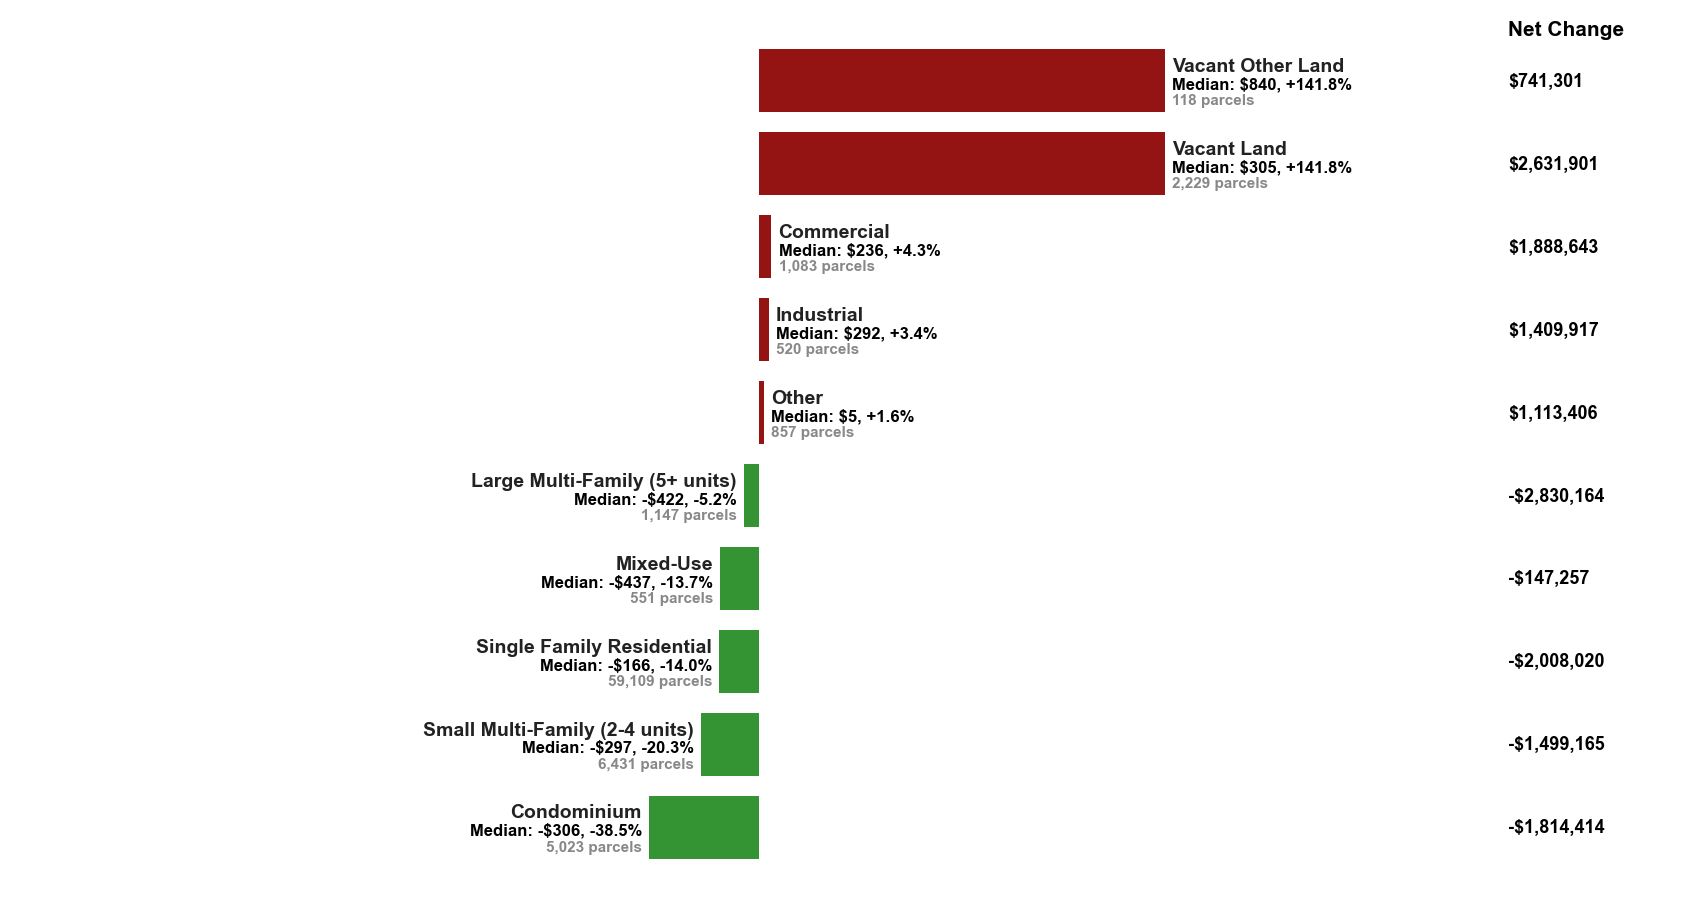

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Only include categories with property_count > 50
filtered = output_summary[output_summary['property_count'] > 50].copy()

categories = filtered['PROPERTY_CATEGORY'].tolist()
counts = filtered['property_count'].tolist()
median_pct_change = filtered['median_tax_change_pct'].tolist()
median_dollar_change = filtered['median_tax_change'].tolist()
total_tax_change = filtered['total_tax_change'].tolist() if 'total_tax_change' in filtered.columns else (filtered['mean_tax_change'] * filtered['property_count']).tolist()

# Sort by median_pct_change ascending
sorted_idx = np.argsort(median_pct_change)
categories = [categories[i] for i in sorted_idx]
counts = [counts[i] for i in sorted_idx]
median_pct_change = [median_pct_change[i] for i in sorted_idx]
median_dollar_change = [median_dollar_change[i] for i in sorted_idx]
total_tax_change = [total_tax_change[i] for i in sorted_idx]

# Custom color: anything above 0 is dark red, below 0 is green
bar_colors = []
for val in median_pct_change:
    if val > 0:
        bar_colors.append("#8B0000")  # dark red
    else:
        bar_colors.append("#228B22")  # professional green

# Bar settings
bar_height = 0.75
fig_height = len(categories) * 0.8 + 1.2
right_col_pad = 120  # more padding for right column
fig, ax = plt.subplots(figsize=(17, fig_height))  # wider for right column

y = np.arange(len(categories))

# Draw bars
ax.barh(
    y, median_pct_change, color=bar_colors, edgecolor='none',
    height=bar_height, alpha=0.92, linewidth=0, zorder=2
)

# Remove all spines and ticks for a clean look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Adjusted vertical spacing
cat_offset = 0.18   # less space between category and median
med_offset = -0.03  # median just below category
count_offset = -0.23  # more space below median for parcels

# For right column: position for total tax change
max_abs = max(abs(min(median_pct_change)), abs(max(median_pct_change)))
right_col_x = max_abs + right_col_pad

# Add Net Change header at the top of the right column
ax.text(
    right_col_x, len(categories) - 0.5, "Net Change", va='bottom', ha='left',
    fontsize=15, fontweight='bold', color='black', fontname='Arial'
)

for i, (cat, val, count, med_dol, tot_change) in enumerate(zip(categories, median_pct_change, counts, median_dollar_change, total_tax_change)):
    # Format median dollar and percent change together
    if med_dol >= 0:
        med_dol_str = f"${med_dol:,.0f}"
    else:
        med_dol_str = f"-${abs(med_dol):,.0f}"
    pct_str = f"{val:+.1f}%"
    median_combo = f"Median: {med_dol_str}, {pct_str}"

    # Position: right of bar for positive, left for negative
    if val < 0:
        xpos = val - 2.5
        ha = 'right'
    else:
        xpos = val + 2.5
        ha = 'left'
    # Category name (bold, bigger)
    ax.text(
        xpos, y[i]+cat_offset, cat, va='center', ha=ha,
        fontsize=14, fontweight='bold', color='#222',
        fontname='Arial'
    )
    # Median (dollar + percent, bold, black, just below category)
    ax.text(
        xpos, y[i]+med_offset, median_combo, va='center', ha=ha,
        fontsize=12, fontweight='bold', color='black',
        fontname='Arial'
    )
    # Count (bold, smaller, below median)
    ax.text(
        xpos, y[i]+count_offset, f"{count:,} parcels", va='center', ha=ha,
        fontsize=11, fontweight='bold', color='#888',
        fontname='Arial'
    )
    # Net change column, always right-aligned in a new column, black text, no "Total:"
    if tot_change >= 0:
        tot_change_str = f"${tot_change:,.0f}"
    else:
        tot_change_str = f"-${abs(tot_change):,.0f}"
    ax.text(
        right_col_x, y[i], tot_change_str, va='center', ha='left',
        fontsize=13, fontweight='bold', color='black',
        fontname='Arial'
    )

# Set x limits for symmetry, make bars longer, and leave space for right column
ax.set_xlim(-right_col_x, right_col_x + 60)

# Remove axis labels/ticks
ax.set_yticks([])
ax.set_xticks([])

plt.tight_layout()
plt.show()


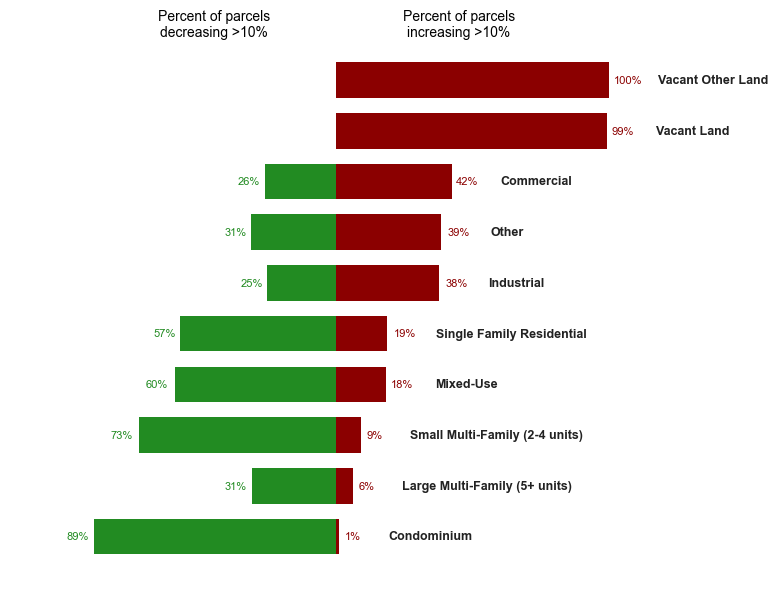

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Use output_summary to generate categories and percent increase/decrease, filtering to count > 50

# Filter to property_count > 50
summary_filtered = output_summary[output_summary['property_count'] > 50].copy()

# Sort by pct_increase_gt_threshold ascending (smallest percent increase first)
summary_sorted = summary_filtered.sort_values('pct_increase_gt_threshold', ascending=True)

categories_sorted = summary_sorted['PROPERTY_CATEGORY'].tolist()
pct_increase_sorted = summary_sorted['pct_increase_gt_threshold'].tolist()
pct_decrease_sorted = summary_sorted['pct_decrease_gt_threshold'].tolist()

# Convert to integers for display
pct_increase_int_sorted = [int(round(x)) for x in pct_increase_sorted]
pct_decrease_int_sorted = [int(round(x)) for x in pct_decrease_sorted]

y = np.arange(len(categories_sorted))

fig, ax = plt.subplots(figsize=(8, 6))

# Use specified colors
color_increase = "#8B0000"  # dark red
color_decrease = "#228B22"  # professional green

# Plot left (decrease) bars (green, to the left)
ax.barh(
    y, 
    [-v for v in pct_decrease_sorted], 
    color=color_decrease, 
    edgecolor='none', 
    height=0.7
)

# Plot right (increase) bars (red, to the right)
ax.barh(
    y, 
    pct_increase_sorted, 
    color=color_increase, 
    edgecolor='none', 
    height=0.7
)

# Add percent labels (integer, no decimals), smaller Arial font
for i, (inc, dec) in enumerate(zip(pct_increase_int_sorted, pct_decrease_int_sorted)):
    # Left side (decrease)
    if dec > 0:
        ax.text(
            -dec - 2, y[i], f"{dec}%", 
            va='center', ha='right', 
            fontsize=8, fontweight='normal', color=color_decrease, fontname='Arial'
        )
    # Right side (increase)
    if inc > 0:
        ax.text(
            inc + 2, y[i], f"{inc}%", 
            va='center', ha='left', 
            fontsize=8, fontweight='normal', color=color_increase, fontname='Arial'
        )

# Add category name at end of right bar, bold, smaller Arial, further from percent
for i, (cat, inc) in enumerate(zip(categories_sorted, pct_increase_sorted)):
    xpos = inc + 18 if inc > 0 else 18
    ax.text(
        xpos, y[i], cat, 
        va='center', ha='left', 
        fontsize=9, fontweight='bold', color='#222', fontname='Arial'
    )

# Remove all spines, ticks, and axis lines for minimalist look
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# Remove grid, axis, and titles
ax.set_yticks([])
ax.set_xticks([])
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('')

# Set xlim for symmetry
max_val = max(max(pct_increase_sorted), max(pct_decrease_sorted))
ax.set_xlim(-max_val-20, max_val+48)

# --- Add custom titles above left and right bars ---
# Make the titles a little bit bigger and closer to the center
title_fontsize = 10  # increased from 8
title_color = 'black'
title_fontweight = 'normal'
title_fontname = 'Arial'

# Compute center x for both titles, but offset slightly left/right of center
title_y = len(categories_sorted) - 0.2

# Left title (above left bars), closer to center
left_title_x = -max_val * 0.45
ax.text(
    left_title_x, title_y, 
    "Percent of parcels\ndecreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)

# Right title (above right bars), closer to center
right_title_x = max_val * 0.45
ax.text(
    right_title_x, title_y, 
    "Percent of parcels\nincreasing >10%", 
    ha='center', va='bottom', fontsize=title_fontsize, fontweight=title_fontweight, 
    color=title_color, fontname=title_fontname, 
    bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.15')
)

plt.tight_layout()
plt.show()


Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 1358.9211
Improvement millage rate: 339.7303
Total tax revenue: $219,433,888.36
Target revenue: $219,433,888.36
Revenue difference: $0.00 (0.0000%)


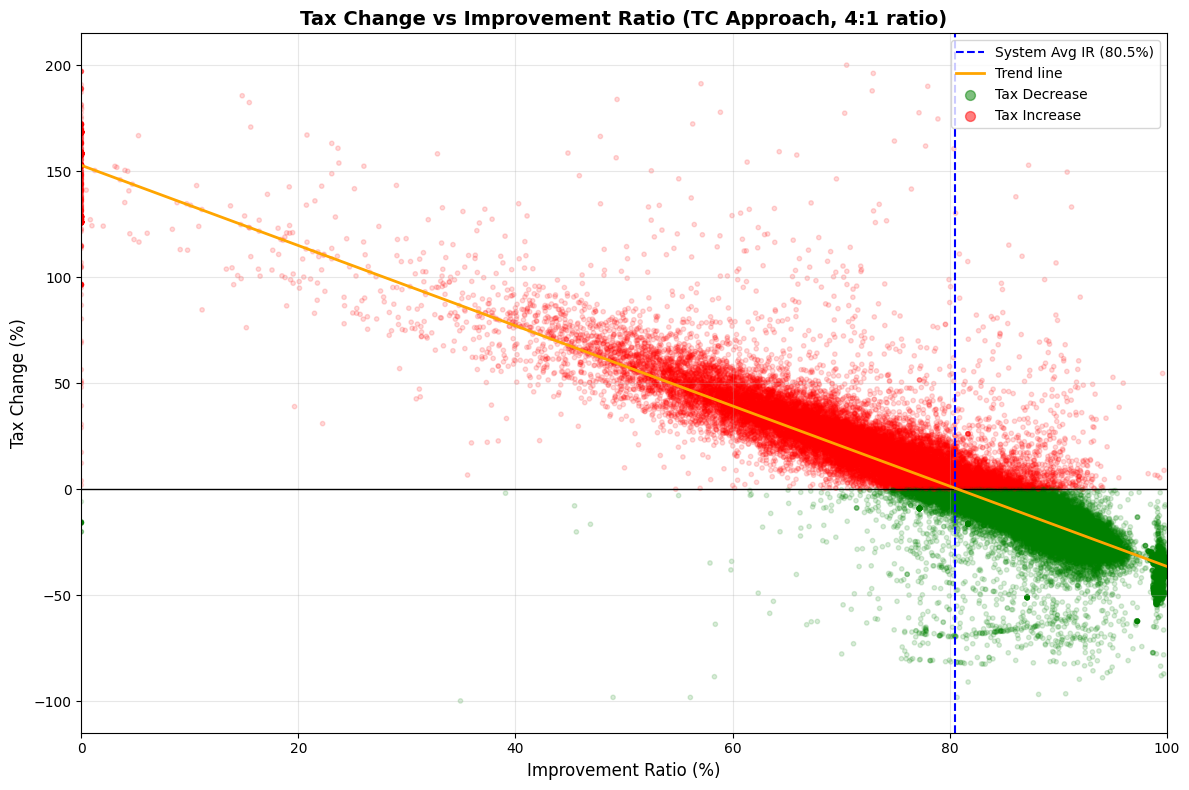


Plot shows 77,164 parcels
  Green (tax decrease): 50,794
  Red (tax increase): 26,370


In [23]:
# Scatter plot: Tax Change vs Improvement Ratio
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# Load fresh data for this plot
ramsey_fresh = gpd.read_parquet('data/st_paul/ramsey_county_20260205.gpq')
plot_source = ramsey_fresh[ramsey_fresh['SiteCityNameUSPS'] == 'ST PAUL'].copy()
plot_source = plot_source[
    (plot_source['TaxCapacity'] > 0) & 
    (plot_source['EMVTotal1'] > 0) &
    (plot_source['TotalTax1'].notna())
].copy()

# Calculate IR and tax capacity components
plot_source['IR'] = plot_source['EMVBuilding1'] / plot_source['EMVTotal1']
plot_source['IR'] = plot_source['IR'].fillna(0)
plot_source['TaxCapacity_Land'] = (1 - plot_source['IR']) * plot_source['TaxCapacity']
plot_source['TaxCapacity_Improvements'] = plot_source['IR'] * plot_source['TaxCapacity']

# Calculate taxes
city_pct = 0.3572
plot_source['current_tax'] = plot_source['TotalTax1'] * city_pct
current_revenue = plot_source['current_tax'].sum()

# Run model with same ratio as main analysis
_, _, _, plot_source = model_split_rate_tax(
    df=plot_source,
    land_value_col='TaxCapacity_Land',
    improvement_value_col='TaxCapacity_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)
plot_source['tax_change_pct'] = np.where(
    plot_source['current_tax'] > 0,
    ((plot_source['new_tax'] - plot_source['current_tax']) / plot_source['current_tax']) * 100,
    0
)

# Filter to parcels with valid data and reasonable tax values
plot_data = plot_source[
    (plot_source['current_tax'] > 100) & 
    (plot_source['IR'].notna()) &
    (plot_source['tax_change_pct'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Color based on tax change: green for decrease, red for increase
colors = np.where(plot_data['tax_change_pct'] < 0, 'green', 'red')

# Create scatter plot with transparency
scatter = ax.scatter(
    plot_data['IR'] * 100,
    plot_data['tax_change_pct'],
    alpha=0.15,
    s=10,
    c=colors
)

# Add reference lines
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

# Calculate and plot the system average IR
system_avg_ir = (plot_source['EMVBuilding1'].sum() / plot_source['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5, 
           label=f'System Avg IR ({system_avg_ir:.1f}%)')

# Add trend line using numpy polyfit
z = np.polyfit(plot_data['IR'] * 100, plot_data['tax_change_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
ax.plot(x_line, p(x_line), 'orange', linewidth=2, label='Trend line')

# Add legend for colors
ax.scatter([], [], c='green', alpha=0.5, s=50, label='Tax Decrease')
ax.scatter([], [], c='red', alpha=0.5, s=50, label='Tax Increase')

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Tax Change vs Improvement Ratio (TC Approach, {tc_land_improvement_ratio}:1 ratio)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/st_paul/tax_change_vs_improvement_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot shows {len(plot_data):,} parcels")
print(f"  Green (tax decrease): {(plot_data['tax_change_pct'] < 0).sum():,}")
print(f"  Red (tax increase): {(plot_data['tax_change_pct'] >= 0).sum():,}")

Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 1358.9211
Improvement millage rate: 339.7303
Total tax revenue: $219,433,888.36
Target revenue: $219,433,888.36
Revenue difference: $0.00 (0.0000%)


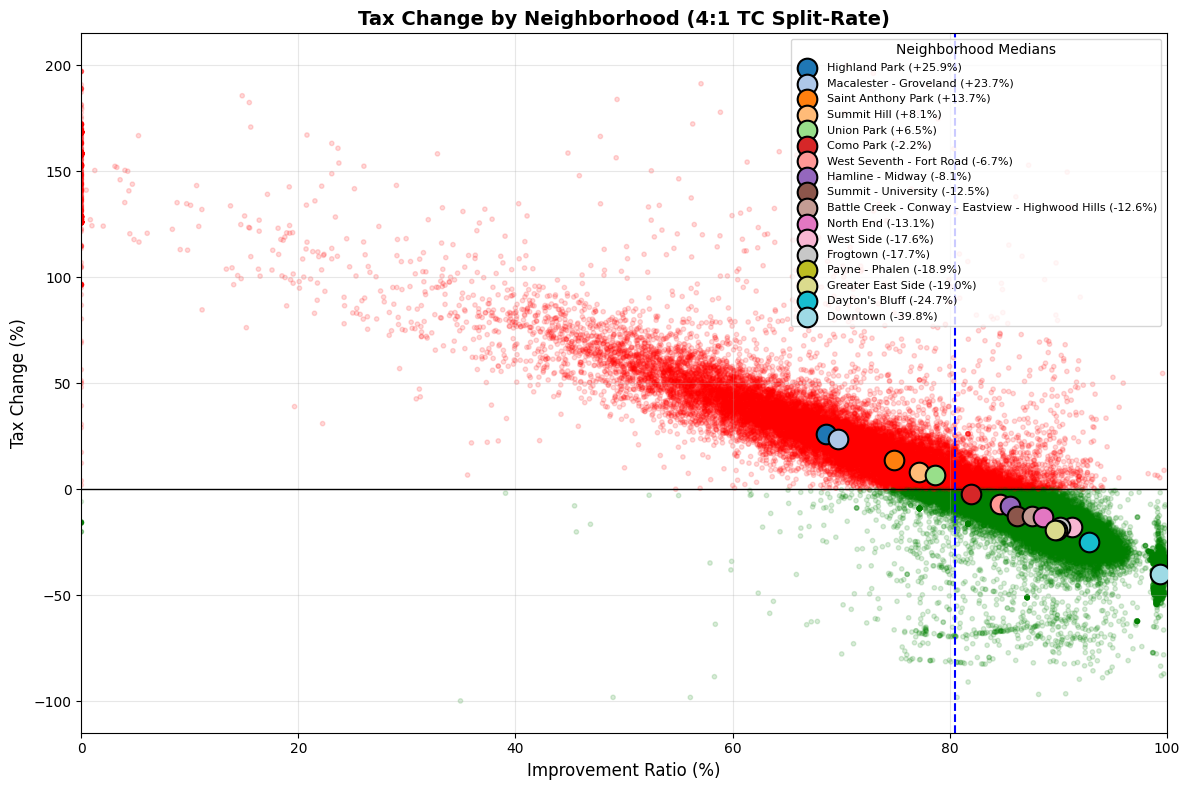


Plot shows 77,160 parcels across 17 neighborhoods
  Green (tax decrease): 50,794
  Red (tax increase): 26,366


In [24]:
# Scatter plot: Tax Change by Neighborhood
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# Load fresh data for this plot
ramsey_fresh = gpd.read_parquet('data/st_paul/ramsey_county_20260205.gpq')
plot_source = ramsey_fresh[ramsey_fresh['SiteCityNameUSPS'] == 'ST PAUL'].copy()
plot_source = plot_source[
    (plot_source['TaxCapacity'] > 0) & 
    (plot_source['EMVTotal1'] > 0) &
    (plot_source['TotalTax1'].notna())
].copy()

# Calculate IR and tax capacity components
plot_source['IR'] = plot_source['EMVBuilding1'] / plot_source['EMVTotal1']
plot_source['IR'] = plot_source['IR'].fillna(0)
plot_source['TaxCapacity_Land'] = (1 - plot_source['IR']) * plot_source['TaxCapacity']
plot_source['TaxCapacity_Improvements'] = plot_source['IR'] * plot_source['TaxCapacity']

# Calculate taxes
city_pct = 0.3572
plot_source['current_tax'] = plot_source['TotalTax1'] * city_pct
current_revenue = plot_source['current_tax'].sum()

# Run model with same ratio as main analysis
_, _, _, plot_source = model_split_rate_tax(
    df=plot_source,
    land_value_col='TaxCapacity_Land',
    improvement_value_col='TaxCapacity_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)
plot_source['tax_change_pct'] = np.where(
    plot_source['current_tax'] > 0,
    ((plot_source['new_tax'] - plot_source['current_tax']) / plot_source['current_tax']) * 100,
    0
)

# Spatial join to District Council neighborhoods
neighborhoods = gpd.read_file('data/st_paul/District_Councils_3386664414246726701')
neighborhoods = neighborhoods[['planning_1', 'geometry']].rename(columns={'planning_1': 'Neighborhood'})
neighborhoods = neighborhoods.to_crs(epsg=3857)

# Join parcels to neighborhoods via centroids
plot_source_3857 = plot_source.to_crs(epsg=3857)
plot_source_3857['centroid'] = plot_source_3857.geometry.centroid
centroids = gpd.GeoDataFrame(plot_source_3857.drop(columns='geometry'), geometry='centroid', crs='EPSG:3857')
plot_source = gpd.sjoin(centroids, neighborhoods, how='left', predicate='within')
plot_source = plot_source.drop(columns=['index_right', 'centroid']).rename(columns={})

# Filter to valid data
plot_data = plot_source[
    (plot_source['current_tax'] > 100) & 
    (plot_source['Neighborhood'].notna()) &
    (plot_source['tax_change_pct'].between(-100, 200))
].copy()

fig, ax = plt.subplots(figsize=(12, 8))

# Color based on tax change: green for decrease, red for increase
colors = np.where(plot_data['tax_change_pct'] < 0, 'green', 'red')

ax.scatter(
    plot_data['IR'] * 100,
    plot_data['tax_change_pct'],
    alpha=0.15,
    s=10,
    c=colors
)

# Calculate neighborhood medians
neighborhood_stats = plot_data.groupby('Neighborhood').agg({
    'IR': 'median',
    'tax_change_pct': 'median',
    'TaxCapacity': 'count'
}).reset_index()
neighborhood_stats.columns = ['Neighborhood', 'median_IR', 'median_tax_change', 'count']
neighborhood_stats = neighborhood_stats.sort_values('median_tax_change', ascending=False)

# Plot neighborhood medians as large colored points
cmap_colors = plt.cm.tab20(np.linspace(0, 1, len(neighborhood_stats)))
for i, row in enumerate(neighborhood_stats.itertuples()):
    ax.scatter(
        row.median_IR * 100,
        row.median_tax_change,
        s=200,
        c=[cmap_colors[i]],
        edgecolors='black',
        linewidths=1.5,
        label=f"{row.Neighborhood} ({row.median_tax_change:+.1f}%)",
        zorder=5
    )

# Reference lines
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (plot_source['EMVBuilding1'].sum() / plot_source['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5)

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Tax Change by Neighborhood ({tc_land_improvement_ratio}:1 TC Split-Rate)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, title='Neighborhood Medians')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/st_paul/tax_change_by_neighborhood_v2.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot shows {len(plot_data):,} parcels across {plot_data['Neighborhood'].nunique()} neighborhoods")
print(f"  Green (tax decrease): {(plot_data['tax_change_pct'] < 0).sum():,}")
print(f"  Red (tax increase): {(plot_data['tax_change_pct'] >= 0).sum():,}")

Split-rate tax model (Land:Improvement = 4:1)
Land millage rate: 1358.9211
Improvement millage rate: 339.7303
Total tax revenue: $219,433,888.36
Target revenue: $219,433,888.36
Revenue difference: $0.00 (0.0000%)


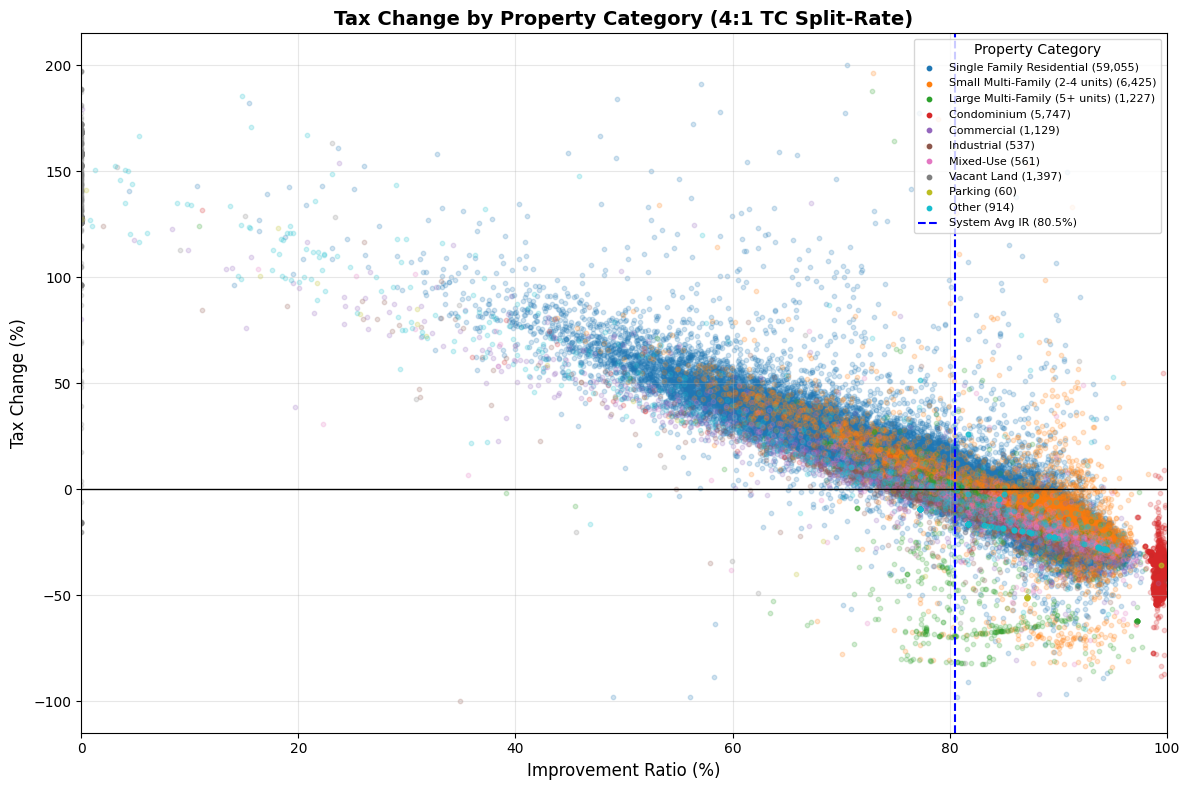


Plot shows 77,164 parcels
  Single Family Residential           59,055 parcels | Median IR:  85.9% | Median Change: -8.0%
  Small Multi-Family (2-4 units)       6,425 parcels | Median IR:  89.4% | Median Change: -12.1%
  Large Multi-Family (5+ units)        1,227 parcels | Median IR:  81.5% | Median Change: -12.0%
  Condominium                          5,747 parcels | Median IR:  99.5% | Median Change: -37.5%
  Commercial                           1,129 parcels | Median IR:  76.0% | Median Change: +1.6%
  Industrial                             537 parcels | Median IR:  77.0% | Median Change: -3.4%
  Mixed-Use                              561 parcels | Median IR:  85.7% | Median Change: -11.7%
  Vacant Land                          1,397 parcels | Median IR:   0.0% | Median Change: +149.3%
  Parking                                 60 parcels | Median IR:  87.1% | Median Change: -35.8%
  Other                                  914 parcels | Median IR:  79.9% | Median Change: -4.6%


In [25]:
# Scatter plot: Tax Change by Property Category
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

# Load fresh data for this plot
ramsey_fresh = gpd.read_parquet('data/st_paul/ramsey_county_20260205.gpq')
plot_source = ramsey_fresh[ramsey_fresh['SiteCityNameUSPS'] == 'ST PAUL'].copy()
plot_source = plot_source[
    (plot_source['TaxCapacity'] > 0) & 
    (plot_source['EMVTotal1'] > 0) &
    (plot_source['TotalTax1'].notna())
].copy()

# Calculate IR and tax capacity components
plot_source['IR'] = plot_source['EMVBuilding1'] / plot_source['EMVTotal1']
plot_source['IR'] = plot_source['IR'].fillna(0)
plot_source['TaxCapacity_Land'] = (1 - plot_source['IR']) * plot_source['TaxCapacity']
plot_source['TaxCapacity_Improvements'] = plot_source['IR'] * plot_source['TaxCapacity']

# Calculate taxes
city_pct = 0.3572
plot_source['current_tax'] = plot_source['TotalTax1'] * city_pct
current_revenue = plot_source['current_tax'].sum()

# Run model with same ratio as main analysis
_, _, _, plot_source = model_split_rate_tax(
    df=plot_source,
    land_value_col='TaxCapacity_Land',
    improvement_value_col='TaxCapacity_Improvements',
    current_revenue=current_revenue,
    land_improvement_ratio=tc_land_improvement_ratio
)
plot_source['tax_change_pct'] = np.where(
    plot_source['current_tax'] > 0,
    ((plot_source['new_tax'] - plot_source['current_tax']) / plot_source['current_tax']) * 100,
    0
)

# Apply property categorization
plot_source['PROPERTY_CATEGORY'] = plot_source.apply(categorize_st_paul_property, axis=1)
vacant_mask = plot_source['LandUseCodeDescription'].str.contains('VACANT', case=False, na=False)
plot_source.loc[vacant_mask, 'PROPERTY_CATEGORY'] = 'Vacant Land'

# Filter to valid data
plot_cat = plot_source[
    (plot_source['current_tax'] > 100) & 
    (plot_source['IR'].notna()) &
    (plot_source['tax_change_pct'].between(-100, 200))
].copy()

category_colors = {
    'Single Family Residential': '#1f77b4',
    'Small Multi-Family (2-4 units)': '#ff7f0e',
    'Large Multi-Family (5+ units)': '#2ca02c',
    'Condominium': '#d62728',
    'Commercial': '#9467bd',
    'Industrial': '#8c564b',
    'Mixed-Use': '#e377c2',
    'Vacant Land': '#7f7f7f',
    'Parking': '#bcbd22',
    'Other': '#17becf',
}

fig, ax = plt.subplots(figsize=(12, 8))

for cat, color in category_colors.items():
    mask = plot_cat['PROPERTY_CATEGORY'] == cat
    subset = plot_cat[mask]
    if len(subset) == 0:
        continue
    ax.scatter(
        subset['IR'] * 100,
        subset['tax_change_pct'],
        alpha=0.2,
        s=10,
        c=color,
        label=f"{cat} ({len(subset):,})"
    )

# Reference lines
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
system_avg_ir = (plot_source['EMVBuilding1'].sum() / plot_source['EMVTotal1'].sum()) * 100
ax.axvline(x=system_avg_ir, color='blue', linestyle='--', linewidth=1.5,
           label=f'System Avg IR ({system_avg_ir:.1f}%)')

ax.set_xlabel('Improvement Ratio (%)', fontsize=12)
ax.set_ylabel('Tax Change (%)', fontsize=12)
ax.set_title(f'Tax Change by Property Category ({tc_land_improvement_ratio}:1 TC Split-Rate)', 
             fontsize=14, fontweight='bold')
legend = ax.legend(loc='upper right', fontsize=8, title='Property Category')
for handle in legend.legend_handles:
    handle.set_alpha(1.0)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/st_paul/tax_change_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nPlot shows {len(plot_cat):,} parcels")
for cat in category_colors:
    n = (plot_cat['PROPERTY_CATEGORY'] == cat).sum()
    if n > 0:
        med_ir = plot_cat.loc[plot_cat['PROPERTY_CATEGORY'] == cat, 'IR'].median() * 100
        med_chg = plot_cat.loc[plot_cat['PROPERTY_CATEGORY'] == cat, 'tax_change_pct'].median()
        print(f"  {cat:<35} {n:>6,} parcels | Median IR: {med_ir:5.1f}% | Median Change: {med_chg:+.1f}%")

## Step 6: Adding Geographic Context

To make our analysis spatially-aware, we need to add geographic boundaries to our parcel data. This enables us to:

- **Create maps** showing tax changes across the city
- **Analyze patterns by neighborhood** or district  
- **Combine with demographic data** for equity analysis
- **Present results visually** to stakeholders

We'll fetch the parcel boundary data from the same ArcGIS service that contains the geometric information for each property.


### Merging Tax Analysis with Geographic Data

Here we combine our tax analysis results with the geographic boundaries. This creates a spatially-enabled dataset that allows us to:

1. **Map tax changes** across South Bend
2. **Identify spatial patterns** in tax impacts
3. **Prepare for demographic analysis** by having geographic context

The merge should give us the same number of records as our original analysis, now with geographic coordinates for each parcel.


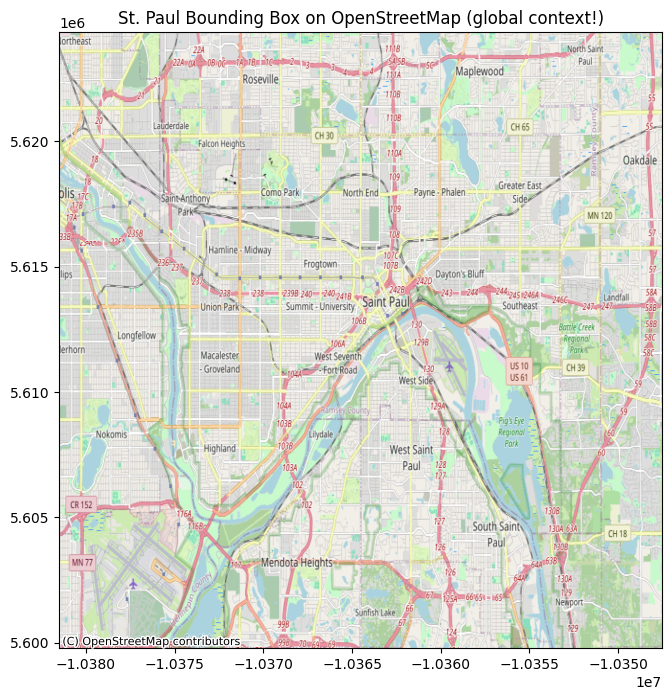

St. Paul parcel data geographic bounds (minx, miny, maxx, maxy):
[-93.207767  44.887762 -93.00432   44.991966]
Sample parcel centroids (longitude, latitude):
21     POINT (-93.02167 44.96372)
59     POINT (-93.01086 44.97156)
176    POINT (-93.02182 44.96373)
204    POINT (-93.07446 44.93098)
300    POINT (-93.07575 44.96778)
dtype: geometry


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2157040375.py:70: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = st_paul_gdf.geometry.centroid


In [26]:
import matplotlib.pyplot as plt
import geopandas as gpd

# Calculate the total bounds of st_paul_gdf: (minx, miny, maxx, maxy)
minx, miny, maxx, maxy = st_paul_gdf.total_bounds

# Create a rectangular polygon for the bounds for visualization
from shapely.geometry import box
bounds_gdf = gpd.GeoDataFrame(
    {"geometry": [box(minx, miny, maxx, maxy)]},
    crs=st_paul_gdf.crs
)

# Plot the St. Paul boundary on a world map using OpenStreetMap (OSM) as a backdrop.
try:
    import contextily as ctx

    # Project the bounds to Web Mercator for OSM compatibility
    bounds_webm = bounds_gdf.to_crs(epsg=4326)
    # Also plot a world background for extra context (we use a wide extent)
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot OSM basemap for the world region
    dummy_world_poly = gpd.GeoDataFrame(
        geometry=[box(-20026376, -20048966, 20026376, 20048966)],  # Full Mercator extent
        crs="EPSG:3857"
    )
    dummy_world_poly.boundary.plot(ax=ax, color="lightgray", linewidth=0.3, zorder=1)

    # Add the bounding box of St. Paul on top
    bounds_webm.boundary.plot(ax=ax, color="red", linewidth=2, zorder=10)
    
    # autoscale to include some margin outside the bounding box
    expand = 1.5
    xmid = (minx + maxx) / 2
    ymid = (miny + maxy) / 2
    width = (maxx - minx) * expand
    height = (maxy - miny) * expand

    bounds = box(
        xmid - width / 2,
        ymid - height / 2,
        xmid + width / 2,
        ymid + height / 2
    )
    bounds_webm_margin = gpd.GeoDataFrame({'geometry': [bounds]}, crs=st_paul_gdf.crs).to_crs(epsg=3857)

    # Set plot extent so you can see the region in context
    bl, tr = bounds_webm_margin.total_bounds.reshape(2,2)
    ax.set_xlim(bl[0], tr[0])
    ax.set_ylim(bl[1], tr[1])

    # Add the OSM basemap for real-world context!
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, alpha=1)
    ax.set_title("St. Paul Bounding Box on OpenStreetMap (global context!)")
    plt.xlabel("")
    plt.ylabel("")
except ImportError:
    ax = bounds_gdf.plot(
        facecolor='none', edgecolor='red', linewidth=2, figsize=(8, 8)
    )
    ax.set_title("St. Paul Parcel Data: Bounding Box (no OSM)")
plt.show()

# Print the geographic coordinates (bounding box) of st_paul_gdf
print("St. Paul parcel data geographic bounds (minx, miny, maxx, maxy):")
print(st_paul_gdf.total_bounds)

# Print a sample of coordinates from all parcels (e.g., the centroid of each geometry)
centroids = st_paul_gdf.geometry.centroid
print("Sample parcel centroids (longitude, latitude):")
print(centroids.head())


In [27]:
# Get census data for Ramsey County
census_data, census_boundaries = get_census_data_with_boundaries(
    fips_code='27123',  # Minnesota (27) + Ramsey County (123)
    year=2022
)

# Set CRS for census boundaries before merging
census_boundaries = census_boundaries.set_crs(epsg=4326)
boundary_gdf = st_paul_city.to_crs(epsg=4326)

# Merge census data with our parcel data
df = match_to_census_blockgroups(
    gdf=boundary_gdf,
    census_gdf=census_boundaries,
    join_type="left"
)

print(f"Number of census blocks: {len(census_boundaries)}")
print(f"Number of census data: {len(census_data)}")
print(f"Number of parcels with census data: {len(df)}")


Number of census blocks: 7753
Number of census data: 471
Number of parcels with census data: 77100


## Step 7: Demographic and Equity Analysis

One of the most important aspects of LVT analysis is understanding the **equity implications** - how does the tax shift affect different income levels and demographic groups?

### Adding Census Data

We'll match each property to its Census Block Group and pull demographic data including:
- **Median household income** 
- **Racial/ethnic composition**
- **Population characteristics**

### Why This Matters

Policy makers need to understand:
- Does the LVT shift disproportionately burden low-income neighborhoods?
- Are there racial equity implications?  
- Does the policy align with broader equity goals?

**Note**: You'll need a Census API key for this section. Get one free at: https://api.census.gov/data/key_signup.html


In [28]:
print("DataFrame columns:")
print(df.columns.tolist())


DataFrame columns:
['OBJECTID_left', 'CountyID', 'ParcelID', 'FIPsCodeParcelID', 'RollType', 'BuildingNumber', 'BuildingNumberSuffix', 'UnitType', 'UnitNumber', 'Unit', 'StreetPrefixDirection', 'StreetPrefixType', 'StreetName', 'StreetSuffixType', 'StreetSuffixDirection', 'StreetNameAll', 'SiteAddress', 'SiteCityNameUSPS', 'SiteCityNameCode', 'SiteCityName', 'SiteZIP5', 'SiteZIP4', 'SiteZIP', 'SiteCityStateZIP', 'OwnershipCategory', 'OwnerLastName', 'OwnerName', 'OwnerName1', 'OwnerName2', 'OwnerAddress1', 'OwnerAddress2', 'OwnerCityStateZIP', 'TaxName1', 'TaxName2', 'TaxAddress1', 'TaxAddress2', 'TaxCityStateZIP', 'HomesteadName1', 'HomesteadName2', 'HomesteadAddress1', 'HomesteadAddress2', 'HomesteadCityStateZIP', 'NeighborhoodCode', 'MunicipalCode', 'TIFDistrict', 'SchoolDistrictNumber', 'SchoolDistrictName', 'WatershedIDTax', 'WatershedDistrictNameTax', 'WatershedDistNamePoly', 'PlatID', 'PlatName', 'TaxDescription', 'Block', 'Lot', 'ParcelAcresDeed', 'ParcelSquareFeet', 'ParcelAcr

### Exploring the Enhanced Dataset

With census data merged in, our dataset now contains both property tax information and demographic context. Let's explore what variables we now have available for analysis.

This enhanced dataset allows us to examine relationships between:
- Property characteristics and demographics
- Tax impacts and neighborhood income levels
- Geographic patterns in tax burden shifts


In [29]:
# Display all columns with maximum width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
display(df.head())


,OBJECTID_left,CountyID,ParcelID,FIPsCodeParcelID,RollType,BuildingNumber,BuildingNumberSuffix,UnitType,UnitNumber,Unit,StreetPrefixDirection,StreetPrefixType,StreetName,StreetSuffixType,StreetSuffixDirection,StreetNameAll,SiteAddress,SiteCityNameUSPS,SiteCityNameCode,SiteCityName,SiteZIP5,SiteZIP4,SiteZIP,SiteCityStateZIP,OwnershipCategory,OwnerLastName,OwnerName,OwnerName1,OwnerName2,OwnerAddress1,OwnerAddress2,OwnerCityStateZIP,TaxName1,TaxName2,TaxAddress1,TaxAddress2,TaxCityStateZIP,HomesteadName1,HomesteadName2,HomesteadAddress1,HomesteadAddress2,HomesteadCityStateZIP,NeighborhoodCode,MunicipalCode,TIFDistrict,SchoolDistrictNumber,SchoolDistrictName,WatershedIDTax,WatershedDistrictNameTax,WatershedDistNamePoly,PlatID,PlatName,TaxDescription,Block,Lot,ParcelAcresDeed,ParcelSquareFeet,ParcelAcresPolygon,ParcelFrontage,TaxYear,EMVYear,EMVLand,EMVBuilding,EMVTotal,TotalTax,SpecialAssessmentDue,TaxCapacity,CostLandValue,TaxYear1,EMVYear1,EMVLand1,EMVBuilding1,EMVTotal1,TotalTax1,SpecialAssessmentDue1,TaxYear2,EMVYear2,EMVLand2,EMVBuilding2,EMVTotal2,TotalTax2,SpecialAssessmentDue2,LandmarkBusinessName,LandUseCode,LandUseCodeDescription,MultipleUseYN,UseTypeCode1,UseType1,UseTypeCode2,UseType2,UseTypeCode3,UseType3,UseTypeCode4,UseType4,TaxExemptYN,ExemptUse1,ExemptUse2,ExemptUse3,ExemptUse4,GreenAcresYN,OpenSpaceYN,AgriculturalPreserveYN,AgPreserveEnrolled,AgPreserveExpire,HomesteadYN,HomesteadDescription,StructureCode,StructureDescription,DwellingType,LivingUnit,HomeStyleCode,HomeStyleDescription,ExteriorWallCode,ExteriorWallDescription,Stories,RoomTotal,BedRoom,FamilyRoom,BasementYN,HeatSystemCode,HeatSystemType,HeatCode,HeatType,LivingAreaSquareFeet,BusinessSquareFeet,GarageYN,GarageSquareFeet,YearBuilt,EffectiveYearBuilt,TopologyCode,TopologyDescription,UtilityCode,UtilityDescription,LastSaleDate,SalePrice,InspectionYear,InspectionStatus,X,Y,Latitude,Longitude,Section,Township,Range,QuarterQuarter,PolygonPointRelationship,PropertyDataJoinDate,InspectionDataJoinDate,EditDate,geometry,in_tif,fully_exempt,pays_city_tax,citytax_per_arbase,city_tax,PROPERTY_CATEGORY,current_tax,land_tax,improvement_tax,new_tax,tax_change,tax_change_pct,IR,TaxCapacity_Improvements,TaxCapacity_Land,new_tax_tc,tax_change_tc,tax_change_pct_tc,abs_tax_diff,OID,STATE,COUNTY,TRACT,BLKGRP,BLOCK,SUFFIX,GEOID,LWBLKTYP,UR,AREAWATER,AREALAND,MTFCC,NAME,BASENAME,LSADC,FUNCSTAT,CENTLON,CENTLAT,INTPTLON,INTPTLAT,HU100,POP100,OBJECTID_right,state_fips,county_fips,tract_fips,bg_fips,std_geoid,median_income,total_pop,white_pop,black_pop,hispanic_pop,state,county,tract,census_block_group,minority_pct,black_pct
21,30796928,27123,262922330217,27123-262922330217,RP,1864,None,None,None,None,None,None,REANEY,AVE,None,REANEY AVE,1864 REANEY AVE,ST PAUL,02396511,SAINT PAUL,55119,3430,55119-3430,SAINT PAUL MN 55119-3430,Unknown,VANG,SIA VANG SANG P LEE,SIA VANG,SANG P LEE,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,SIA VANG,None,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,SANG P LEE,SIA VANG,1864 REANEY AVE,None,SAINT PAUL MN 55119-3430,00011001,02,None,0625,St. Paul School District,034,METRO WATERSHED,Ramsey-Washington Metro WSD,00302,AURORA ADDITION,AURORA ADDITION PART LYING E OF THE FOL DESC ...,8,9,0.10,4356.0,0.10,38.0,2025.0,2024.0,30000.0,287200.0,317200.0,4884.38,215.62,2992.0,30000.0,2024.0,2023.0,25000.0,255600.0,280600.0,4062.08,167.92,2023.0,2022.0,25000.0,281700.0,306700.0,4567.58,162.42,None,510,"SINGLE FAMILY DWELLING, PLATTED LOT",N,201,1A/1B/4BB RESIDENTIAL SINGLE UNIT,None,None,None,None,None,None,N,None,None,None,None,N,N,N,None,None,Y,FULL HOMESTEAD,None,None,"SINGLE FAMILY DWELLING, PLATTED LOT",1.0,07,TWO STORY,6,ALUM/VINYL,2.0,7.0,3.0,NaN,Y,1,HOT AIR,4,CENTW/AIR,1536.0,NaN,N,NaN,2010.0,2010.0,2,ABOVE STREET,1,ALL PUBLIC,1.403136e+12,190000.0,2021,Property reviewed 7/26/2021,593620.13,163145.63,44.963723,-93.021665,26,29,22,SWSW,1,1.769731e+12,1.769731e+12,1395531084000,"POLYGON ((-93.0216 44.96356, -93.02175 44.9635...",False,False,True,1.357

### Viewing the Complete Dataset

Let's examine our enhanced dataset with all the variables we've created and merged. This gives us a comprehensive view of each property with:

- **Property characteristics** (type, value, location)
- **Current tax calculations** 
- **New LVT calculations**
- **Tax change impacts**
- **Demographic context** (income, race/ethnicity)

This rich dataset forms the foundation for sophisticated equity and impact analysis.


Number of rows in gdf_filtered: 74798
Number of rows in non_vacant_gdf: 72679


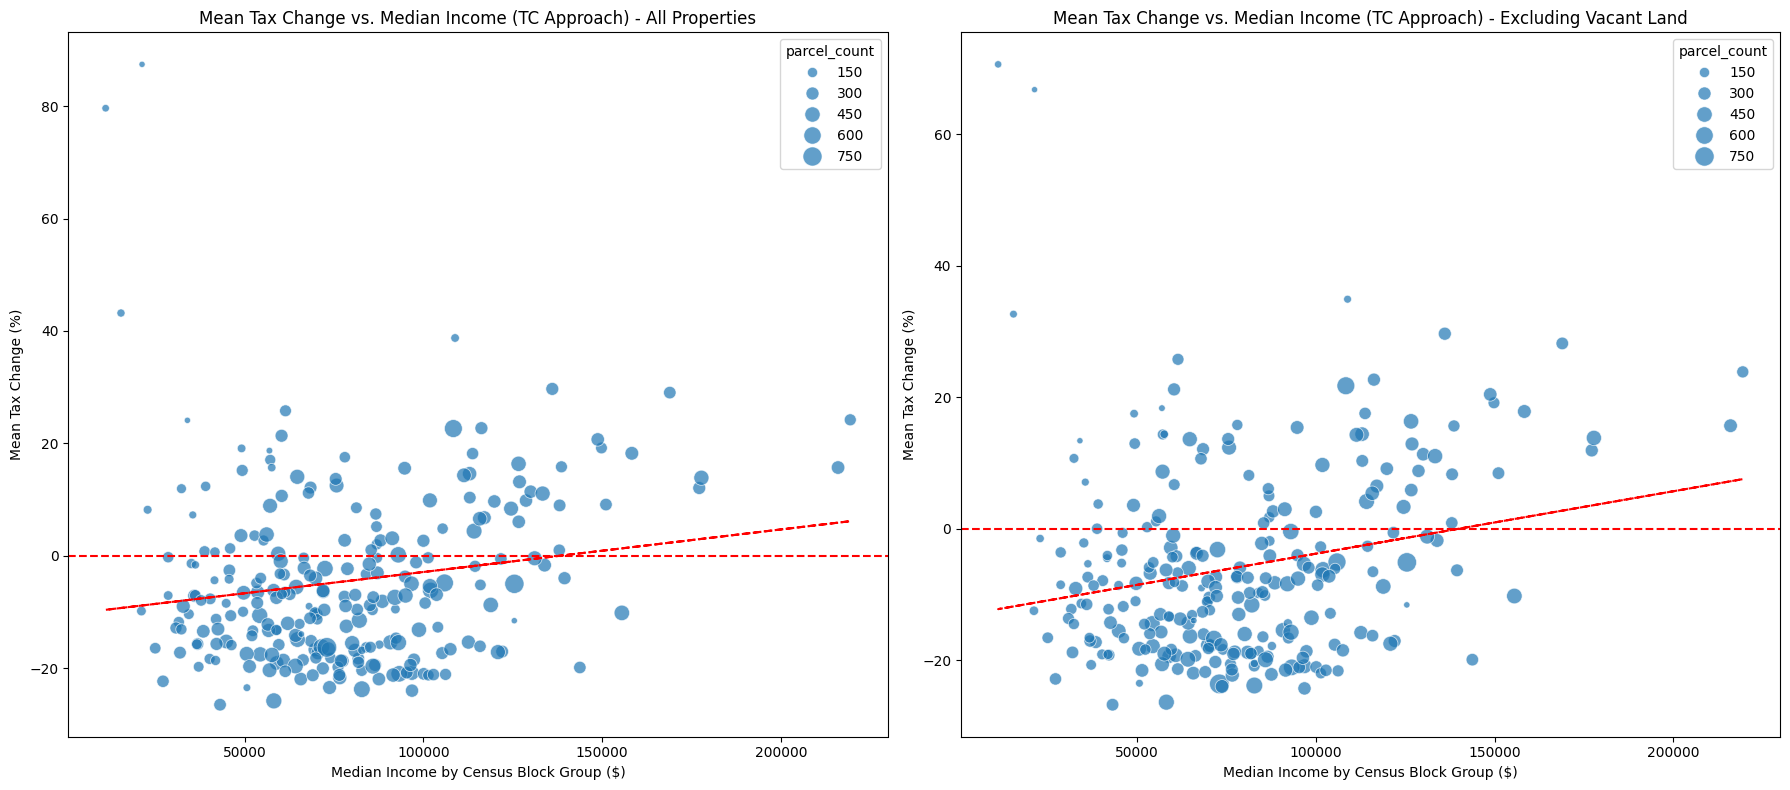

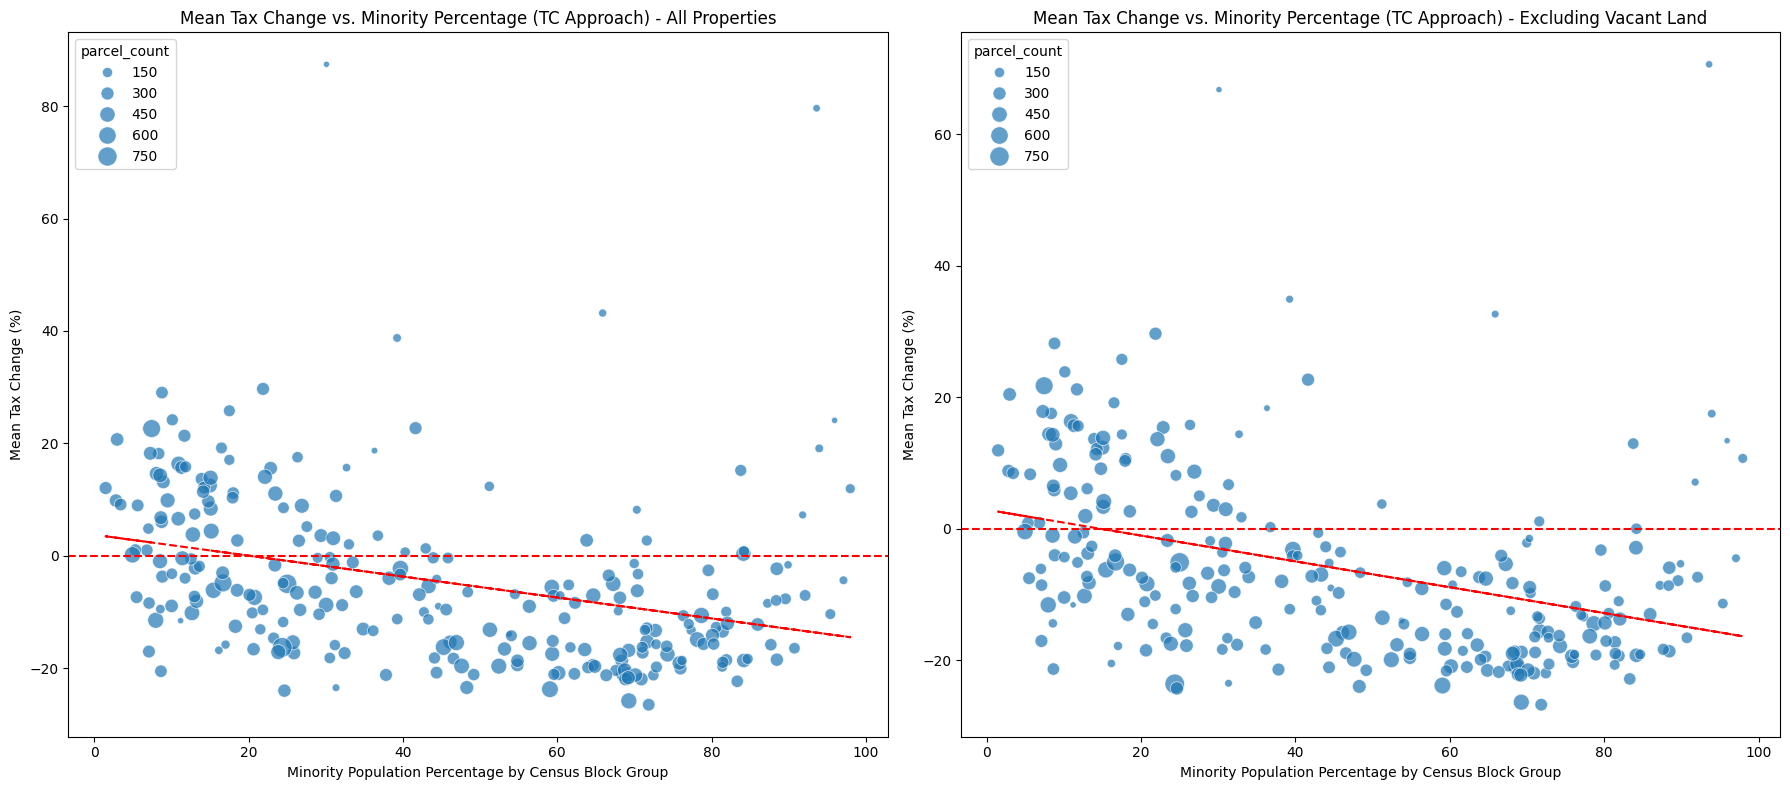

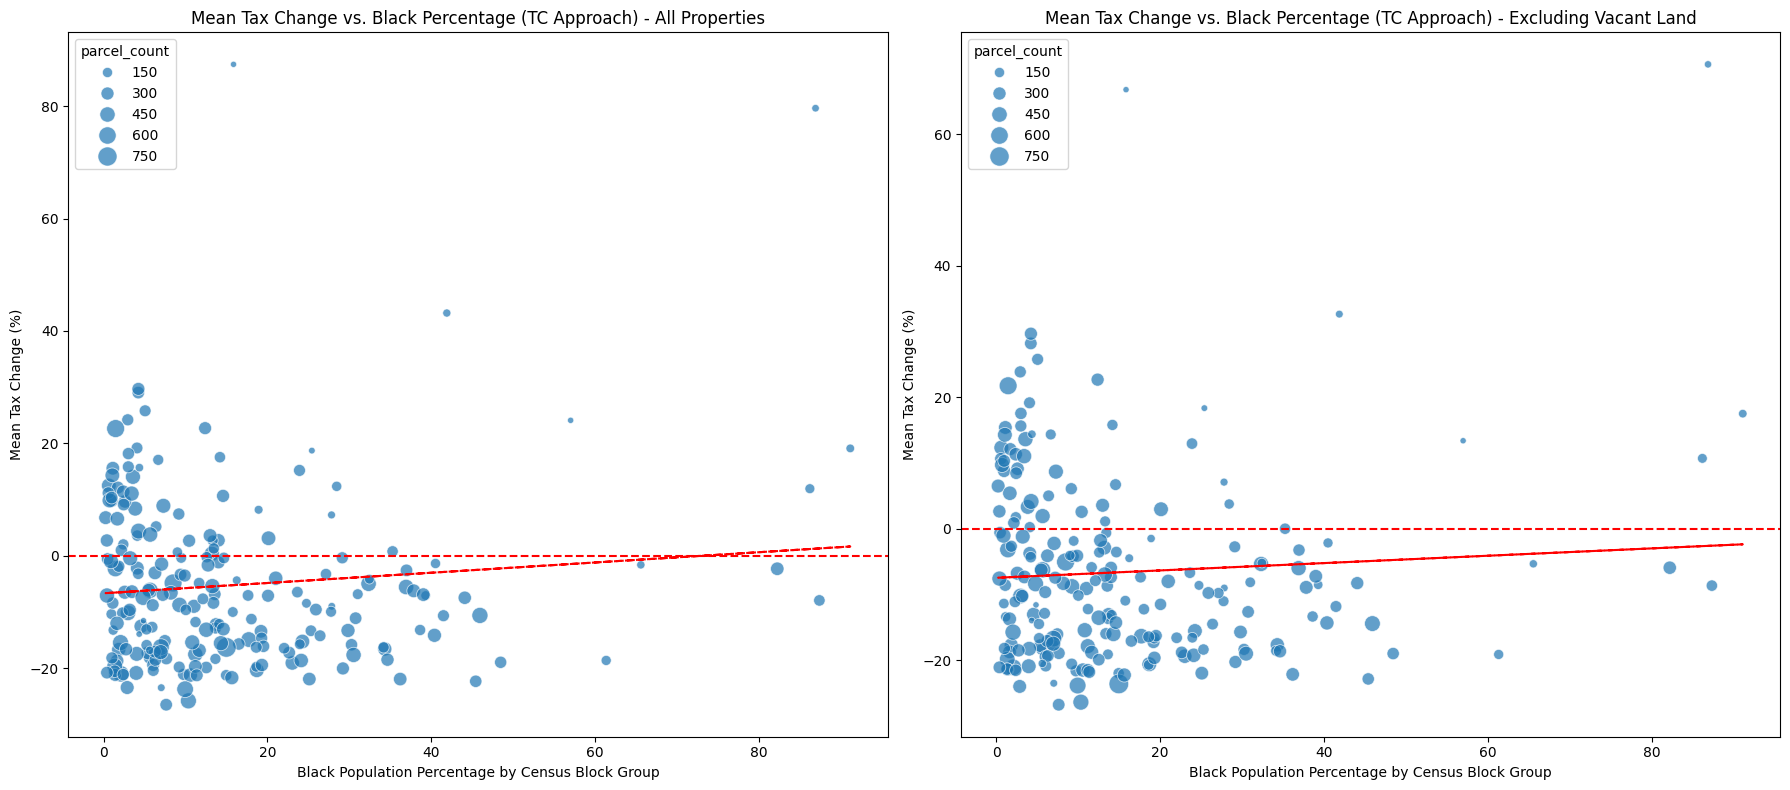

Correlation income_mean_all: 0.1693
Correlation income_median_all: 0.3514
Correlation minority_mean_all: -0.3327
Correlation black_mean_all: 0.0474
Correlation income_mean_non_vacant: 0.2241
Correlation income_median_non_vacant: 0.4355
Correlation minority_mean_non_vacant: -0.3707
Correlation black_mean_non_vacant: 0.0122


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: FutureWarning: The default of observed=False is deprecated and 


Tax impact by income quintile (all properties) - TC Approach:


/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(f'{group_col}_quintile').apply(
/var/folders/cc/hk3rly2j56s77pw2m5b987sw0000gn/T/ipykernel_68590/2805793447.py:118: DeprecationWarning: DataFrameGroupBy.apply operated on the grou

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),15088.0,-6.879972,-19.071554,44132.583908
1,Q2,15252.0,-5.564317,-17.723176,63841.095201
2,Q3,14654.0,-10.728584,-17.762141,79199.097243
3,Q4,15016.0,-7.614772,-15.105391,97319.477557
4,Q5 (Highest),14788.0,8.952494,7.041574,134173.733703


...

,median_income_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14651.0,-14.665842,-19.423866,44531.793529
1,Q2,14623.0,-11.753911,-18.697100,64251.705874
2,Q3,14545.0,-13.708640,-17.884864,79621.765418
3,Q4,14695.0,-9.487220,-14.816125,98102.606261
4,Q5 (Highest),14165.0,7.054643,6.305965,135000.049276



Tax impact by minority percentage quintile (all properties) - TC Approach:


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),15042.0,6.966849,3.951727,9.031673
1,Q2,15050.0,0.581336,-3.958071,20.425218
2,Q3,14898.0,-6.405074,-14.649428,37.903944
3,Q4,14998.0,-12.761001,-21.121592,62.436264
4,Q5 (Highest),14810.0,-10.437188,-20.673748,79.725745



Tax impact by minority percentage quintile (excluding vacant land) - TC Approach:


,minority_pct_quintile,count,mean_tax_change_pct,median_tax_change_pct,mean_value
0,Q1 (Lowest),14824.0,4.993404,3.479008,9.027395
1,Q2,14319.0,-1.976492,-4.848384,20.198408
2,Q3,14503.0,-9.689512,-14.033310,37.198269
3,Q4,14568.0,-18.437660,-21.380123,61.780675
4,Q5 (Highest),14465.0,-18.127795,-21.008528,79.451269


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def filter_data(df):
    """Filter data to remove negative or zero median incomes and create non-vacant subset (also with positive income)"""
    df_filtered = df[df['median_income'] > 0].copy()
    non_vacant_df = df[(df['PROPERTY_CATEGORY'] != 'Vacant Land') & (df['median_income'] > 0)].copy()
    return df_filtered, non_vacant_df

def calculate_block_group_summary(df):
    """Calculate summary statistics for census block groups, excluding negative/zero median incomes"""
    # Only include block groups with positive median income
    df = df[df['median_income'] > 0].copy()
    summary = df.groupby('std_geoid').agg(
        median_income=('median_income', 'first'),
        minority_pct=('minority_pct', 'first'),
        black_pct=('black_pct', 'first'),
        total_current_tax=('current_tax', 'sum'),
        total_new_tax=('new_tax_tc', 'sum'),
        mean_tax_change=('tax_change_tc', 'mean'),
        median_tax_change=('tax_change_tc', 'median'),
        median_tax_change_pct=('tax_change_pct_tc', 'median'),
        parcel_count=('tax_change_tc', 'count'),
        has_vacant_land=('PROPERTY_CATEGORY', lambda x: 'Vacant Land' in x.values)
    ).reset_index()
    # Exclude block groups with non-positive median income (shouldn't be needed, but for safety)
    summary = summary[summary['median_income'] > 0].copy()
    summary['mean_tax_change_pct'] = ((summary['total_new_tax'] - summary['total_current_tax']) / 
                                    summary['total_current_tax']) * 100
    return summary

def create_scatter_plot(data, x_col, y_col, ax, title, xlabel, ylabel):
    """Create a scatter plot with trend line, excluding negative/zero incomes"""
    # Exclude rows with non-positive x_col (e.g., median_income)
    data = data[data[x_col] > 0].copy()
    sns.scatterplot(
        data=data,
        x=x_col,
        y=y_col,
        size='parcel_count',
        sizes=(20, 200),
        alpha=0.7,
        ax=ax
    )
    
    ax.axhline(y=0, color='r', linestyle='--')
    
    x = data[x_col].dropna()
    y = data[y_col].dropna()
    mask = ~np.isnan(x) & ~np.isnan(y)
    
    if len(x[mask]) > 1:
        z = np.polyfit(x[mask], y[mask], 1)
        p = np.poly1d(z)
        ax.plot(x[mask], p(x[mask]), "r--")
    
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

def plot_comparison(data1, data2, x_col, y_col, title_prefix, xlabel):
    """Create side-by-side comparison plots, excluding negative/zero incomes"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    create_scatter_plot(data1, x_col, y_col, ax1, 
                       f'{title_prefix} - All Properties', xlabel, 'Mean Tax Change (%)')
    create_scatter_plot(data2, x_col, y_col, ax2,
                       f'{title_prefix} - Excluding Vacant Land', xlabel, 'Mean Tax Change (%)')
    
    plt.tight_layout()
    plt.show()

def calculate_correlations(data1, data2):
    """Calculate correlations between variables, excluding negative/zero incomes"""
    correlations = {}
    for df, suffix in [(data1, 'all'), (data2, 'non_vacant')]:
        # Exclude rows with non-positive median_income for correlation
        df_corr = df[df['median_income'] > 0].copy()
        correlations[f'income_mean_{suffix}'] = df_corr[['median_income', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'income_median_{suffix}'] = df_corr[['median_income', 'median_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'minority_mean_{suffix}'] = df_corr[['minority_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
        correlations[f'black_mean_{suffix}'] = df_corr[['black_pct', 'mean_tax_change_pct']].corr().iloc[0, 1]
    return correlations

def weighted_median(values, weights):
    """Compute the weighted median of values with corresponding weights."""
    # Remove NaNs
    mask = (~np.isnan(values)) & (~np.isnan(weights))
    values = np.array(values)[mask]
    weights = np.array(weights)[mask]
    if len(values) == 0:
        return np.nan
    sorter = np.argsort(values)
    values = values[sorter]
    weights = weights[sorter]
    cumsum = np.cumsum(weights)
    cutoff = weights.sum() / 2.0
    return values[np.searchsorted(cumsum, cutoff)]

def create_quintile_summary(df, group_col, value_col):
    """Create summary statistics by quintiles, using mean/weighted-median tax change percent, excluding negative/zero incomes for income-based quintiles"""
    # If grouping by income, exclude non-positive values
    if group_col == 'median_income':
        df = df[df['median_income'] > 0].copy()
    df[f'{group_col}_quintile'] = pd.qcut(df[group_col], 5, 
                                         labels=["Q1 (Lowest)", "Q2", "Q3", "Q4", "Q5 (Highest)"])
    
    def weighted_median_tax_change_pct(subdf):
        # Use parcel_count as weights if available, else weight each row equally
        if 'parcel_count' in subdf.columns:
            weights = subdf['parcel_count']
        else:
            weights = np.ones(len(subdf))
        return weighted_median(subdf['tax_change_pct_tc'], weights)
    
    # For this context, each row is a parcel, so weight by 1 (or by parcel_count if already aggregated)
    summary = df.groupby(f'{group_col}_quintile').apply(
        lambda g: pd.Series({
            'count': g['tax_change_tc'].count(),
            'mean_tax_change_pct': g['tax_change_pct_tc'].mean(),
            'median_tax_change_pct': weighted_median(g['tax_change_pct_tc'], np.ones(len(g))),
            'mean_value': g[value_col].mean()
        })
    ).reset_index()
    
    return summary

# Main execution
gdf_filtered, non_vacant_gdf = filter_data(df)
print(f"Number of rows in gdf_filtered: {len(gdf_filtered)}")
print(f"Number of rows in non_vacant_gdf: {len(non_vacant_gdf)}")

# Calculate block group summaries (all with positive median_income only)
census_block_groups = calculate_block_group_summary(gdf_filtered)
non_vacant_block_summary = calculate_block_group_summary(non_vacant_gdf)

# Create comparison plots (all with positive median_income only)
plot_comparison(census_block_groups, non_vacant_block_summary, 
               'median_income', 'mean_tax_change_pct', 
               'Mean Tax Change vs. Median Income (TC Approach)', 
               'Median Income by Census Block Group ($)')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'minority_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Minority Percentage (TC Approach)',
               'Minority Population Percentage by Census Block Group')

plot_comparison(census_block_groups, non_vacant_block_summary,
               'black_pct', 'mean_tax_change_pct',
               'Mean Tax Change vs. Black Percentage (TC Approach)',
               'Black Population Percentage by Census Block Group')

# Calculate and print correlations (all with positive median_income only)
correlations = calculate_correlations(census_block_groups, non_vacant_block_summary)
for key, value in correlations.items():
    print(f"Correlation {key}: {value:.4f}")

# Create and display quintile summaries (income quintiles exclude negative/zero incomes)
income_quintile_summary = create_quintile_summary(gdf_filtered, 'median_income', 'median_income')
non_vacant_income_quintile_summary = create_quintile_summary(non_vacant_gdf, 'median_income', 'median_income')
minority_quintile_summary = create_quintile_summary(gdf_filtered, 'minority_pct', 'minority_pct')
non_vacant_minority_quintile_summary = create_quintile_summary(non_vacant_gdf, 'minority_pct', 'minority_pct')

print("\nTax impact by income quintile (all properties) - TC Approach:")
display(income_quintile_summary)
print("\nTax impact by income quintile (excluding vacant land) - TC Approach:")
display(non_vacant_income_quintile_summary)
print("\nTax impact by minority percentage quintile (all properties) - TC Approach:")
display(minority_quintile_summary)
print("\nTax impact by minority percentage quintile (excluding vacant land) - TC Approach:")
display(non_vacant_minority_quintile_summary)

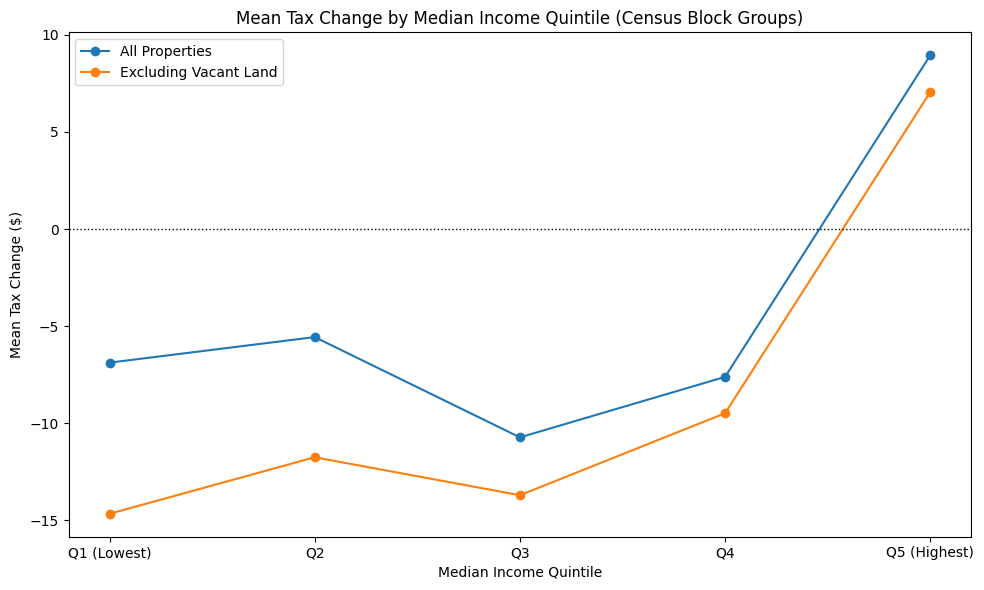

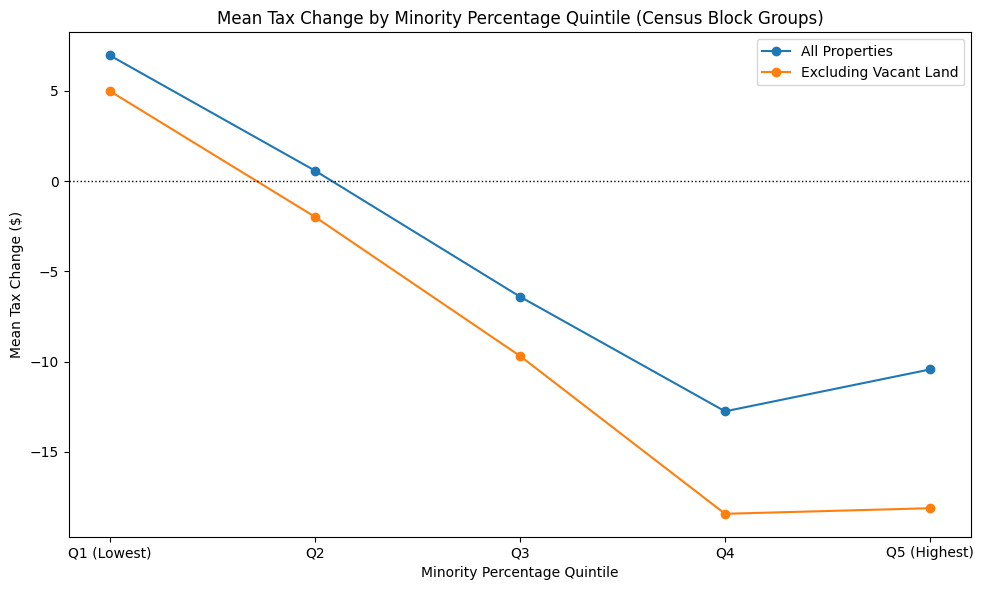

In [31]:
# Plot 1: Median Income Quintiles vs. Mean Tax Change Percent (Census Block Groups)

plt.figure(figsize=(10, 6))
plt.plot(
    income_quintile_summary['median_income_quintile'],
    income_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='All Properties'
)
plt.plot(
    non_vacant_income_quintile_summary['median_income_quintile'],
    non_vacant_income_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Median Income Quintile')
plt.ylabel('Mean Tax Change ($)')
plt.title('Mean Tax Change by Median Income Quintile (Census Block Groups)')
plt.legend()
# Remove grid
# Ensure x-axis at y=0 if negative values present
ymin = min(
    income_quintile_summary['mean_tax_change_pct'].min(),
    non_vacant_income_quintile_summary['mean_tax_change_pct'].min()
)
ymax = max(
    income_quintile_summary['mean_tax_change_pct'].max(),
    non_vacant_income_quintile_summary['mean_tax_change_pct'].max()
)
if ymin < 0 < ymax:
    plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

# Plot 2: Minority Percentage Quintiles vs. Mean Tax Change Percent (Census Block Groups)

plt.figure(figsize=(10, 6))
plt.plot(
    minority_quintile_summary['minority_pct_quintile'],
    minority_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='All Properties'
)
plt.plot(
    non_vacant_minority_quintile_summary['minority_pct_quintile'],
    non_vacant_minority_quintile_summary['mean_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Mean Tax Change ($)')
plt.title('Mean Tax Change by Minority Percentage Quintile (Census Block Groups)')
plt.legend()
# Remove grid
# Ensure x-axis at y=0 if negative values present
ymin2 = min(
    minority_quintile_summary['mean_tax_change_pct'].min(),
    non_vacant_minority_quintile_summary['mean_tax_change_pct'].min()
)
ymax2 = max(
    minority_quintile_summary['mean_tax_change_pct'].max(),
    non_vacant_minority_quintile_summary['mean_tax_change_pct'].max()
)
if ymin2 < 0 < ymax2:
    plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()


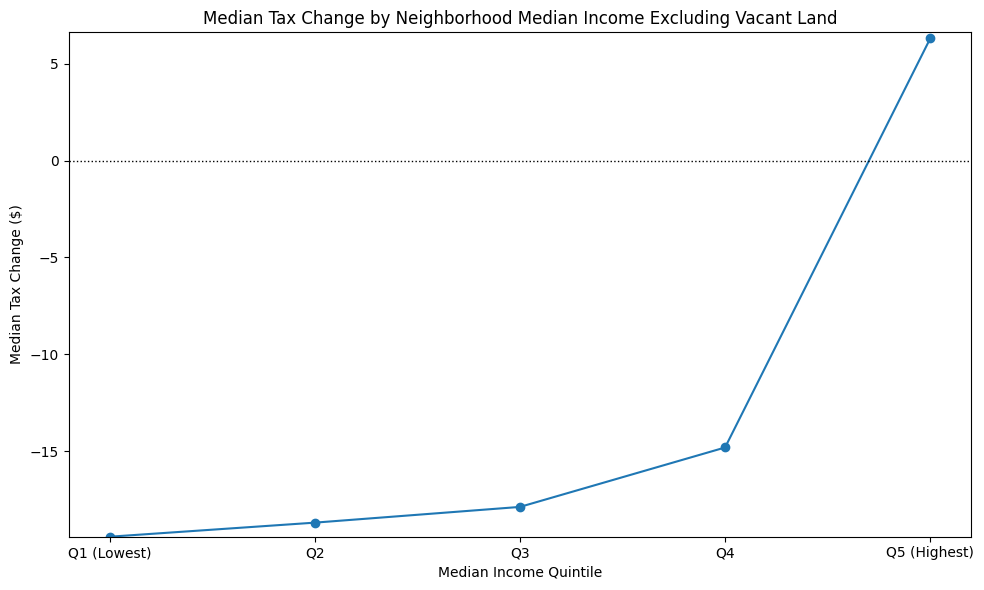

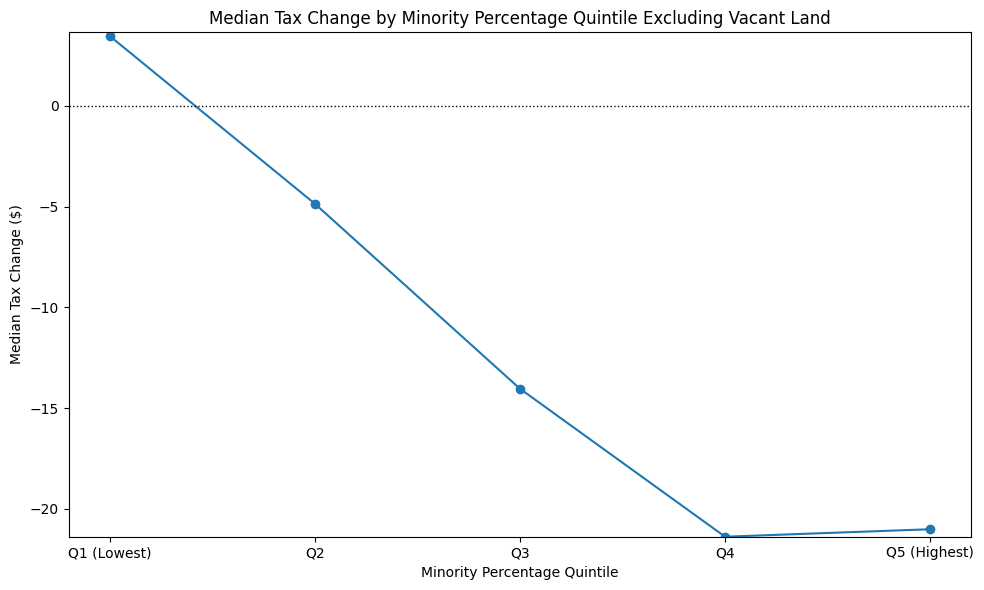

In [32]:
# Plot: Median Tax Change by Neighborhood Median Income Excluding Vacant Land

plt.figure(figsize=(10, 6))
plt.plot(
    non_vacant_income_quintile_summary['median_income_quintile'],
    non_vacant_income_quintile_summary['median_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Median Income Quintile')
plt.ylabel('Median Tax Change ($)')
plt.title('Median Tax Change by Neighborhood Median Income Excluding Vacant Land')
ymin = non_vacant_income_quintile_summary['median_tax_change_pct'].min()
ymax = non_vacant_income_quintile_summary['median_tax_change_pct'].max()
# Ensure 0 is included on the y-axis
plt.ylim(min(ymin, 0), max(ymax, 0) if ymax < 0 else max(ymax, 0, 1.05*ymax))
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()

# Plot: Median Tax Change by Minority Percentage Quintile Excluding Vacant Land

plt.figure(figsize=(10, 6))
plt.plot(
    non_vacant_minority_quintile_summary['minority_pct_quintile'],
    non_vacant_minority_quintile_summary['median_tax_change_pct'],
    marker='o',
    label='Excluding Vacant Land'
)
plt.xlabel('Minority Percentage Quintile')
plt.ylabel('Median Tax Change ($)')
plt.title('Median Tax Change by Minority Percentage Quintile Excluding Vacant Land')
ymin2 = non_vacant_minority_quintile_summary['median_tax_change_pct'].min()
ymax2 = non_vacant_minority_quintile_summary['median_tax_change_pct'].max()
# Ensure 0 is included on the y-axis
plt.ylim(min(ymin2, 0), max(ymax2, 0) if ymax2 < 0 else max(ymax2, 0, 1.05*ymax2))
plt.axhline(0, color='black', linewidth=1, linestyle='dotted')
plt.tight_layout()
plt.show()


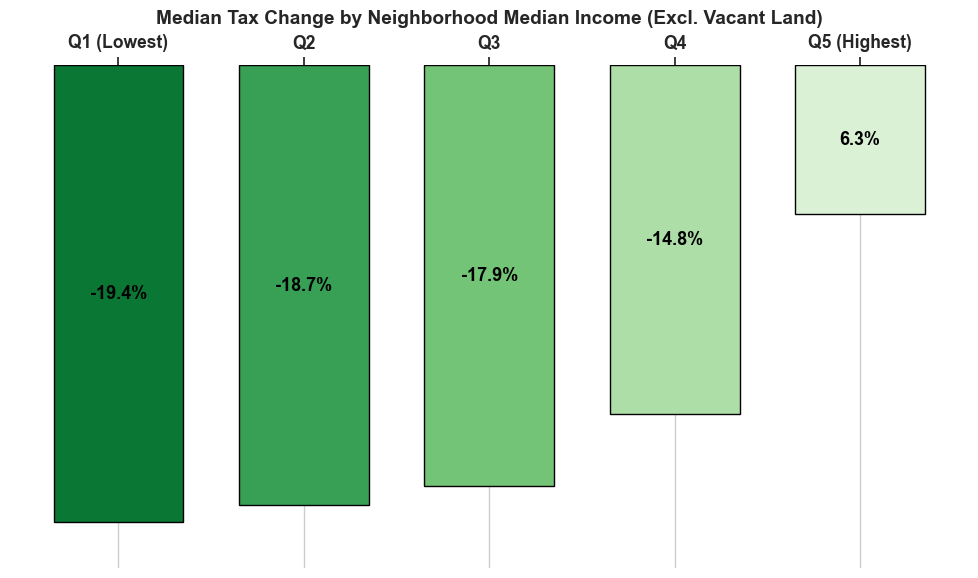

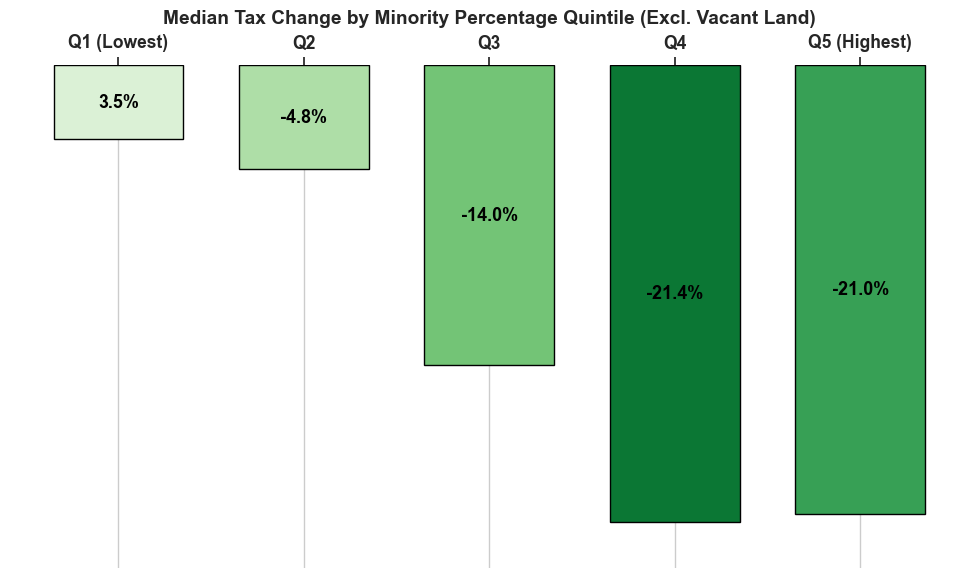

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a modern style
sns.set_theme(style="whitegrid", font_scale=1.15)

# Upside Down Bar Graph: Median Tax Change by Neighborhood Median Income Excluding Vacant Land
fig, ax = plt.subplots(figsize=(10, 6))

vals = non_vacant_income_quintile_summary['median_tax_change_pct']
labels = non_vacant_income_quintile_summary['median_income_quintile']

# Color mapping: dark green (more negative) to light green (less negative)
colors = sns.color_palette("Greens", n_colors=len(vals))
# Sort so that the most negative (largest magnitude) is darkest
color_map = [colors[i] for i in np.argsort(np.argsort(-vals))]

# To make bars start at the top and go down, invert the y-axis and plot positive heights
bars = ax.bar(
    labels,
    np.abs(vals),
    color=color_map,
    edgecolor='black',
    width=0.7
)

# Invert the y-axis so bars start at the top and go down
ax.invert_yaxis()

# Remove y-axis
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Neighborhood Median Income (Excl. Vacant Land)', weight='bold', pad=30)

# Remove all spines (including bottom)
sns.despine(left=True, right=True, top=True, bottom=True)

# Add value labels (bold, % sign) centered inside each bar (no line below the bar)
for bar, val in zip(bars, vals):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

# Move x-tick labels to the top
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

# Set y-limits to show bars going down from the top
ymax = np.abs(vals).max() * 1.1
ax.set_ylim(ymax, 0)

plt.tight_layout()
plt.show()

# Upside Down Bar Graph: Median Tax Change by Minority Percentage Quintile Excluding Vacant Land
fig, ax = plt.subplots(figsize=(10, 6))

vals2 = non_vacant_minority_quintile_summary['median_tax_change_pct']
labels2 = non_vacant_minority_quintile_summary['minority_pct_quintile']

colors2 = sns.color_palette("Greens", n_colors=len(vals2))
color_map2 = [colors2[i] for i in np.argsort(np.argsort(-vals2))]

bars2 = ax.bar(
    labels2,
    np.abs(vals2),
    color=color_map2,
    edgecolor='black',
    width=0.7
)

ax.invert_yaxis()
ax.yaxis.set_visible(False)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title('Median Tax Change by Minority Percentage Quintile (Excl. Vacant Land)', weight='bold', pad=30)
sns.despine(left=True, right=True, top=True, bottom=True)

for bar, val in zip(bars2, vals2):
    ax.annotate(
        f"{val:.1f}%",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2),
        xytext=(0, 0),
        textcoords="offset points",
        ha='center', va='center',
        fontsize=13, color='black', fontweight='bold'
    )

ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.xticks(fontweight='bold')

ymax2 = np.abs(vals2).max() * 1.1
ax.set_ylim(ymax2, 0)

plt.tight_layout()
plt.show()


In [34]:
# Restrict df to only residential property categories
residential_categories = ['Single Family Residential', 'Large Multi-Family (5+ units)', 'Small Multi-Family (2-4)']
df_residential = df[df['PROPERTY_CATEGORY'].isin(residential_categories)].copy()

print(f"Residential parcels: {len(df_residential):,}")
print(df_residential['PROPERTY_CATEGORY'].value_counts())

# Filter data for residential (positive income, non-vacant)
gdf_residential_filtered, non_vacant_residential_gdf = filter_data(df_residential)

# Calculate block group summaries for residential only
census_block_groups_res = calculate_block_group_summary(gdf_residential_filtered)
non_vacant_block_summary_res = calculate_block_group_summary(non_vacant_residential_gdf)

# Create quintile summaries for residential
income_quintile_summary_res = calculate_median_percentage_by_quintile(census_block_groups_res, 'median_income', 'median_tax_change_pct')
non_vacant_income_quintile_summary_res = calculate_median_percentage_by_quintile(non_vacant_block_summary_res, 'median_income', 'median_tax_change_pct')

print("\nResidential Income Quintile Summary (TC Approach):")
print(non_vacant_income_quintile_summary_res)

Residential parcels: 60,256
PROPERTY_CATEGORY
Single Family Residential        59109
Large Multi-Family (5+ units)     1147
Name: count, dtype: int64



Residential Income Quintile Summary (TC Approach):
  median_income_quintile  count  median_value  mean_value  mean_median_income
0            Q1 (Lowest)   51.0    -17.113574  -16.374248        38121.470588
1                     Q2   50.0    -18.931841  -12.158983        59406.000000
2                     Q3   50.0    -19.561420  -14.403679        75025.120000
3                     Q4   50.0    -12.565023  -10.298659        93392.140000
4           Q5 (Highest)   50.0      8.373774    4.880206       131747.200000


/Users/matthewhockert/Desktop/Personal Info/LVTShift/examples/../census_utils.py:605: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(
/Users/matthewhockert/Desktop/Personal Info/LVTShift/examples/../census_utils.py:605: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = work_df.groupby(f'{group_col}_quintile').apply(


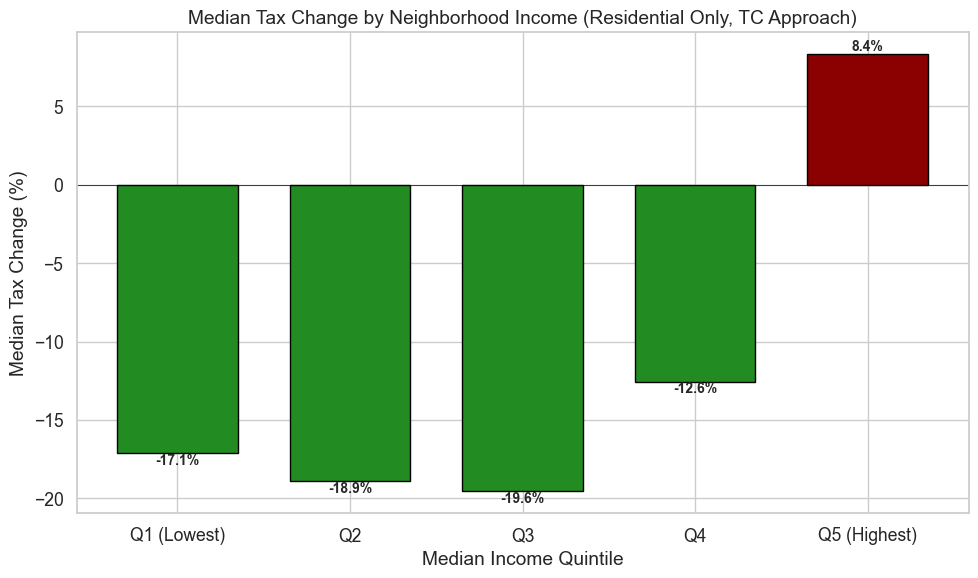

In [35]:
# Bar chart: Median Tax Change by Income Quintile (Residential Only) - TC Approach
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

vals = non_vacant_income_quintile_summary_res['median_value'].values
labels = non_vacant_income_quintile_summary_res['median_income_quintile'].values

bar_colors = ["#8B0000" if v > 0 else "#228B22" for v in vals]

bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', width=0.7)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('Median Income Quintile')
ax.set_ylabel('Median Tax Change (%)')
ax.set_title('Median Tax Change by Neighborhood Income (Residential Only, TC Approach)')

for bar, val in zip(bars, vals):
    ax.annotate(f"{val:.1f}%", 
                xy=(bar.get_x() + bar.get_width()/2, val),
                ha='center', va='bottom' if val >= 0 else 'top',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 9: The Incentive Effect — When Does Investment Pay Off?

1056 Everett Ct faces a tax increase under the split-rate system. But because improvements are taxed at a **lower rate**, every dollar of investment costs less in additional tax than it would under the current system. At some point, the split-rate becomes the cheaper system — the property owner can "invest past" the increase.

This chart plots the annual city tax under both systems as the owner adds improvement value, showing the break-even point.

1056 EVERETT CT — current tax: $2,281, split-rate tax: $2,677 (+$396)
Crossover at $190,184 in improvements — beyond that, the split-rate is cheaper.


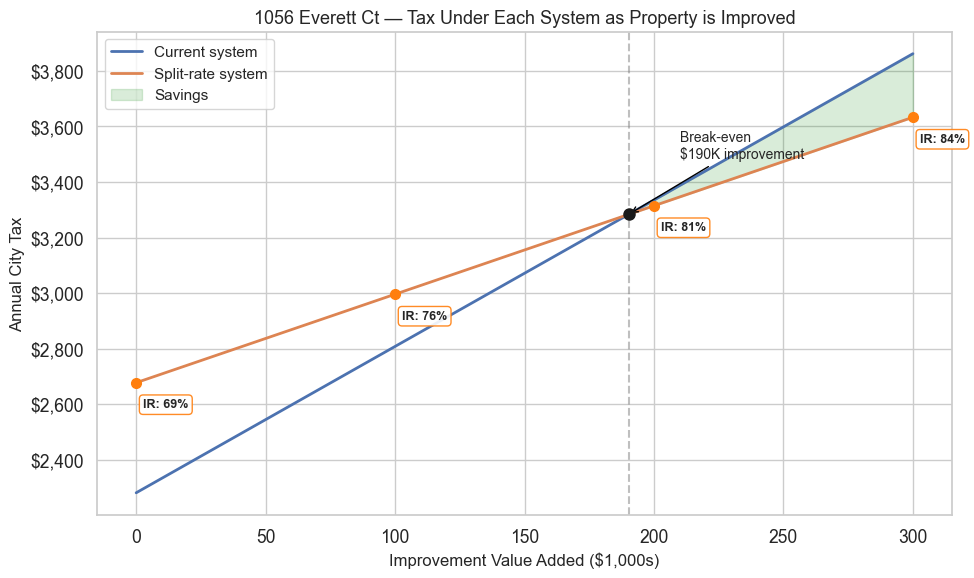

In [36]:
# 1056 Everett Ct: how improvement changes the tax comparison
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('1056 EVERETT', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']
emv_bldg = prop['EMVBuilding1']
emv_total = prop['EMVTotal1']
residential_class_rate = 0.01  # MN class rate for residential homestead under $500K

# Range of improvement values: $0 to $300K
reno_values = np.arange(0, 300_001, 1_000)

# Tax under each system as improvement increases
current_system_tax = current_tax_base + city_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

# Crossover point: where split-rate becomes cheaper
gap = split_tax_base - current_tax_base
rate_advantage = city_tax_rate - tc_imp_millage / 1000
crossover = gap / (rate_advantage * residential_class_rate)
crossover_tax = current_tax_base + city_tax_rate * crossover * residential_class_rate

print(f"1056 EVERETT CT — current tax: ${current_tax_base:,.0f}, split-rate tax: ${split_tax_base:,.0f} (+${gap:,.0f})")
print(f"Crossover at ${crossover:,.0f} in improvements — beyond that, the split-rate is cheaper.")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

# Shade green only AFTER the crossover
mask = reno_values >= crossover
ax.fill_between(reno_values[mask] / 1000, split_rate_tax[mask], current_system_tax[mask],
                alpha=0.15, color='green', label='Savings')

# Mark the crossover
ax.axvline(x=crossover / 1000, color='gray', linestyle='--', alpha=0.5)
ax.plot(crossover / 1000, crossover_tax, 'ko', markersize=8, zorder=5)
ax.annotate(f'Break-even\n${crossover/1000:.0f}K improvement',
            xy=(crossover / 1000, crossover_tax),
            xytext=(crossover / 1000 + 20, crossover_tax + 200),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

# Annotate improvement ratio at every $100K on the split-rate line
for reno in [0, 100_000, 200_000, 300_000]:
    ir = (emv_bldg + reno) / (emv_total + reno)
    idx = int(reno / 1000)
    tax_at_point = split_rate_tax[idx]
    ax.plot(reno / 1000, tax_at_point, 'o', color='tab:orange', markersize=7, zorder=5)
    ax.annotate(f'IR: {ir*100:.0f}%',
                xy=(reno / 1000, tax_at_point),
                xytext=(5, -18), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='tab:orange', alpha=0.9))

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual City Tax', fontsize=12)
ax.set_title('1056 Everett Ct — Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

719 Hague Ave starts with a **tax cut** under the split-rate — the lines are flipped. And because improvements are still taxed at the lower rate, every dollar of investment widens the savings further.

719 HAGUE AVE — current tax: $2,717, split-rate tax: $2,516 (-$201)
Savings grow from $201/year (no improvement) to $827/year ($300K improvement)


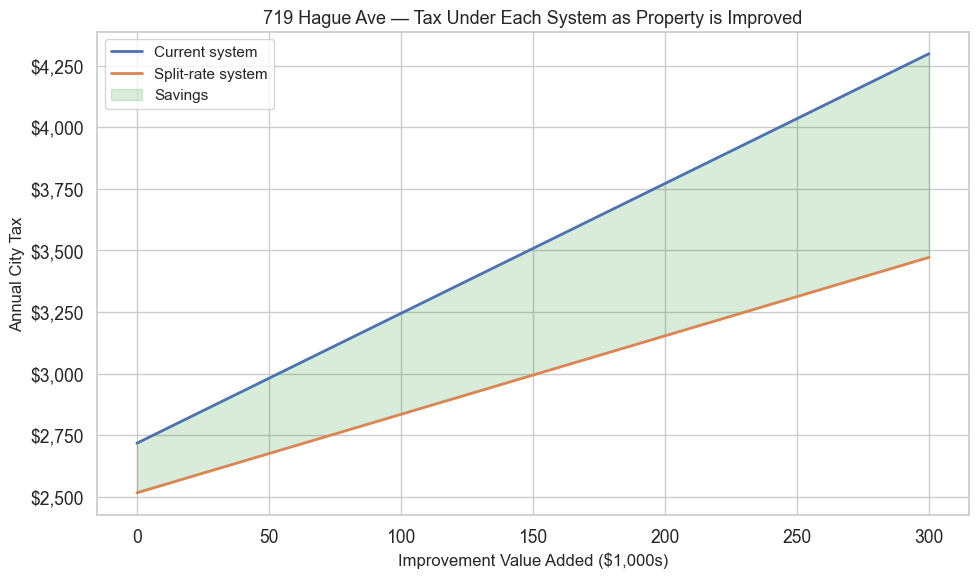

In [37]:
# 719 Hague Ave: split-rate already cheaper, and improvement widens the gap
prop = st_paul_city[st_paul_city['SiteAddress'].str.contains('719 HAGUE', case=False, na=False)].iloc[0]

current_tax_base = prop['current_tax']
split_tax_base = prop['new_tax_tc']

reno_values = np.arange(0, 300_001, 1_000)

current_system_tax = current_tax_base + city_tax_rate * reno_values * residential_class_rate
split_rate_tax = split_tax_base + (tc_imp_millage / 1000) * reno_values * residential_class_rate

savings_at_0 = current_tax_base - split_tax_base
savings_at_300k = current_system_tax[-1] - split_rate_tax[-1]

print(f"719 HAGUE AVE — current tax: ${current_tax_base:,.0f}, split-rate tax: ${split_tax_base:,.0f} (-${savings_at_0:,.0f})")
print(f"Savings grow from ${savings_at_0:,.0f}/year (no improvement) to ${savings_at_300k:,.0f}/year ($300K improvement)")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(reno_values / 1000, current_system_tax, label='Current system', linewidth=2)
ax.plot(reno_values / 1000, split_rate_tax, label='Split-rate system', linewidth=2)

# Shade the savings area
ax.fill_between(reno_values / 1000, split_rate_tax, current_system_tax, alpha=0.15, color='green', label='Savings')

ax.set_xlabel('Improvement Value Added ($1,000s)', fontsize=12)
ax.set_ylabel('Annual City Tax', fontsize=12)
ax.set_title('719 Hague Ave — Tax Under Each System as Property is Improved', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.tight_layout()
plt.show()